<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Loan_Eligibility_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d avineshprabhakaran/loan-eligibility-prediction

# Unziping the downloaded file
!unzip loan-eligibility-prediction.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/avineshprabhakaran/loan-eligibility-prediction
License(s): apache-2.0
  0% 0.00/7.39k [00:00<?, ?B/s]
100% 7.39k/7.39k [00:00<00:00, 31.8MB/s]
Archive:  loan-eligibility-prediction.zip
  inflating: Loan Eligibility Prediction.csv  


In [7]:
df = pd.read_csv('Loan Eligibility Prediction.csv')
df.head(11)

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
5,148,Male,Yes,1,Graduate,No,1538,1425.0,30,360,1,Urban,Y
6,271,Female,No,0,Graduate,No,3237,0.0,30,360,1,Urban,Y
7,29,Male,No,0,Not Graduate,No,1442,0.0,35,360,1,Urban,N
8,583,Female,Yes,0,Graduate,No,3166,0.0,36,360,1,Semiurban,Y
9,510,Female,No,1,Graduate,No,13262,0.0,40,360,1,Urban,Y


In [8]:
df.tail(11)

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
603,306,Male,No,0,Not Graduate,No,2000,0.0,30,360,1,Urban,N
604,323,Male,Yes,2,Not Graduate,No,3601,1590.0,15,360,1,Rural,Y
605,339,Female,No,4,Not Graduate,No,1830,0.0,35,360,0,Urban,N
606,388,Male,Yes,0,Not Graduate,No,3010,3136.0,25,360,0,Urban,N
607,436,Female,No,0,Graduate,No,10047,0.0,30,240,1,Semiurban,Y
608,438,Male,Yes,0,Graduate,No,2213,1125.0,20,360,1,Urban,Y
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y


In [10]:
df.shape

(614, 13)

In [11]:
df.columns

Index(['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status'],
      dtype='object')

In [12]:
df.dtypes

,0
Customer_ID,int64
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
Applicant_Income,int64
Coapplicant_Income,float64
Loan_Amount,int64
Loan_Amount_Term,int64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [15]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,614.0,NaN,NaN,NaN,307.5,177.390811,1.0,154.25,307.5,460.75,614.0
Gender,614,2,Male,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,614,2,Yes,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,614.0,NaN,NaN,NaN,0.856678,1.216651,0.0,0.0,0.0,2.0,4.0
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,614,2,No,523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Applicant_Income,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
Coapplicant_Income,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
Loan_Amount,614.0,NaN,NaN,NaN,142.022801,87.083089,9.0,98.0,125.0,164.75,700.0
Loan_Amount_Term,614.0,NaN,NaN,NaN,338.892508,69.716355,12.0,360.0,360.0,360.0,480.0


In [16]:
df.isnull().sum()

,0
Customer_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Applicant_Income,0
Coapplicant_Income,0
Loan_Amount,0
Loan_Amount_Term,0


In [18]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

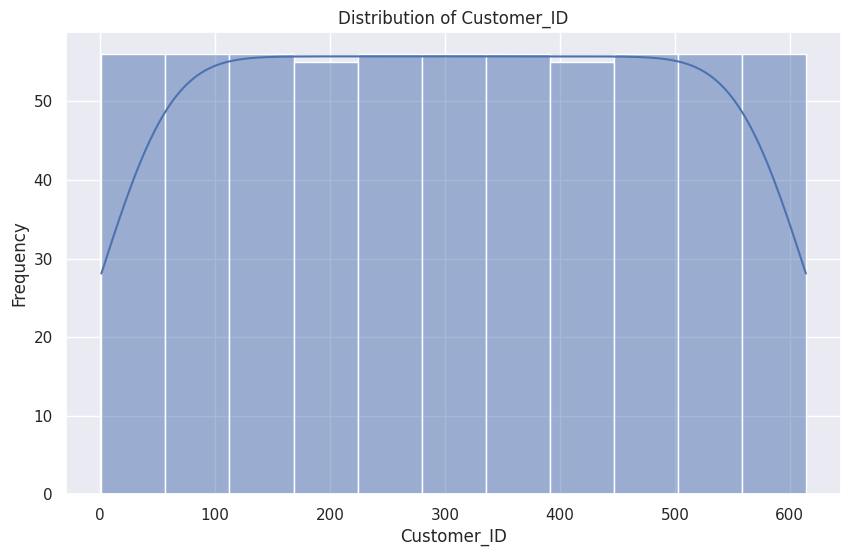

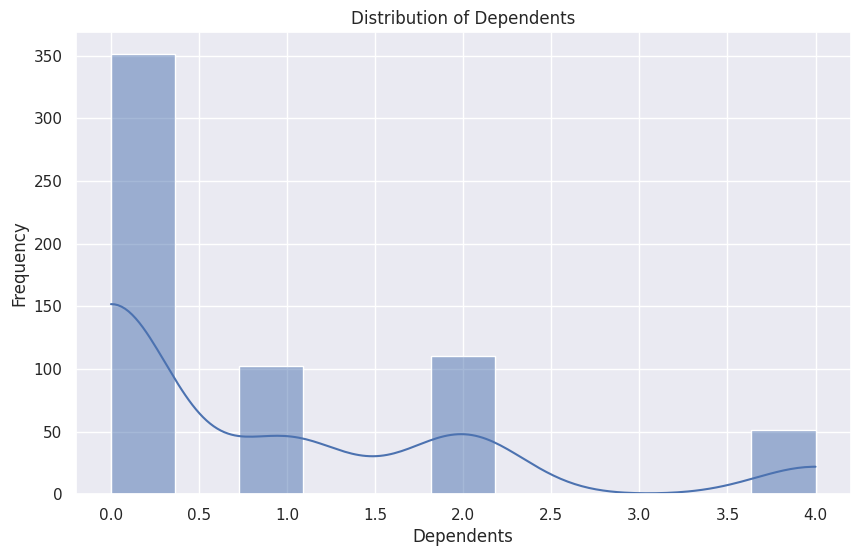

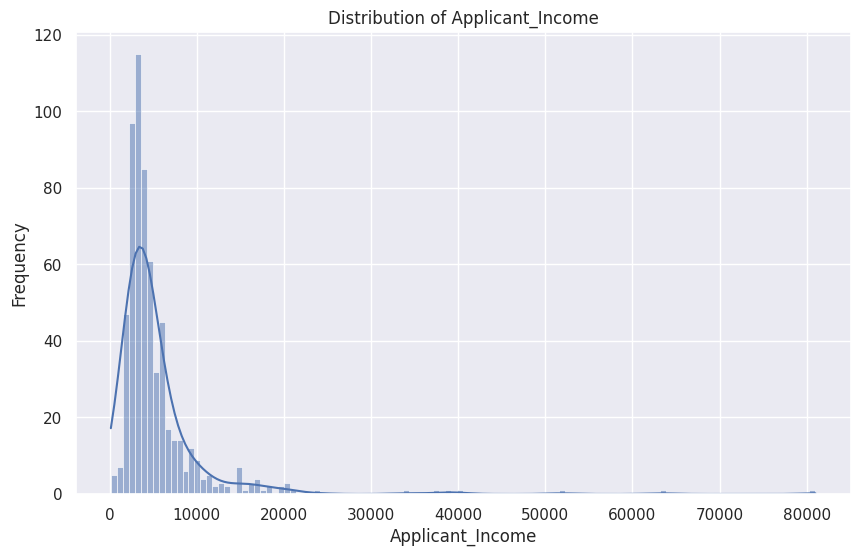

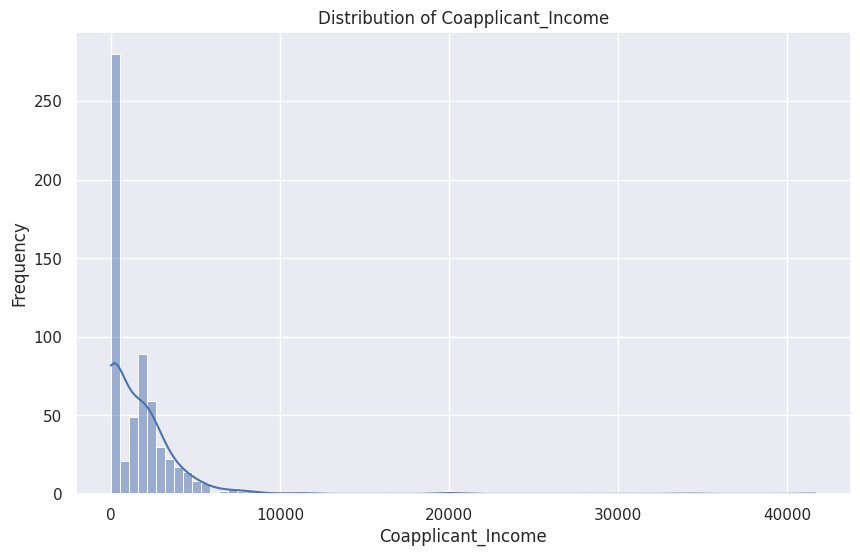

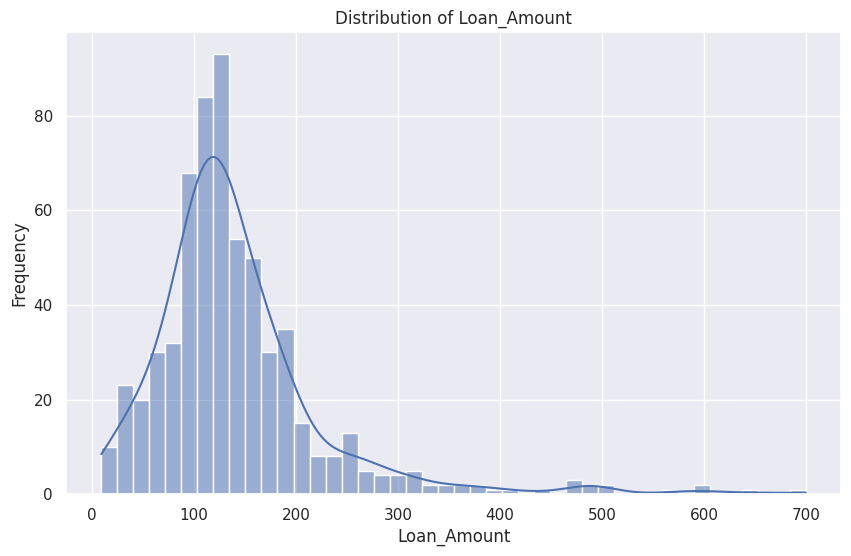

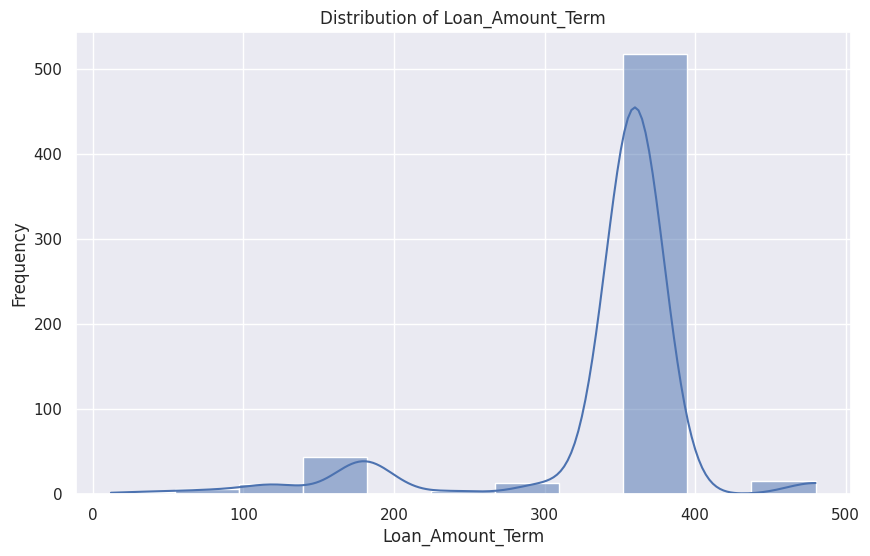

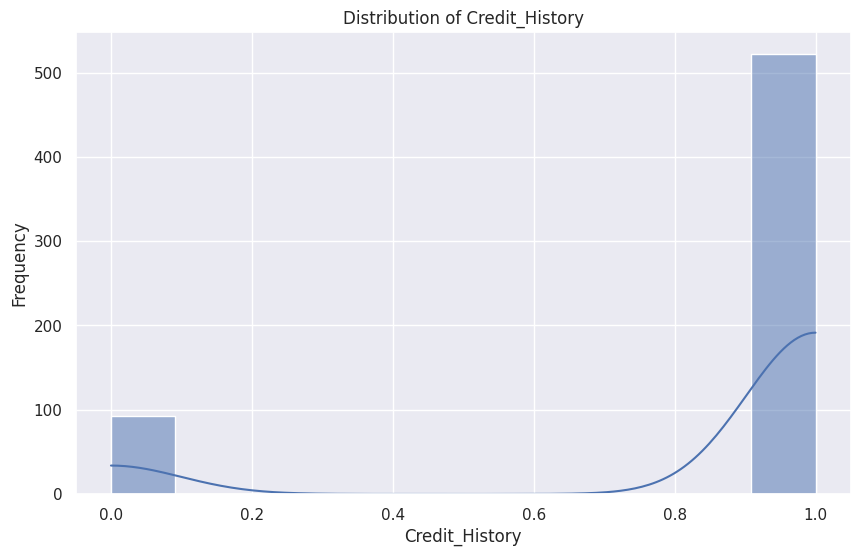

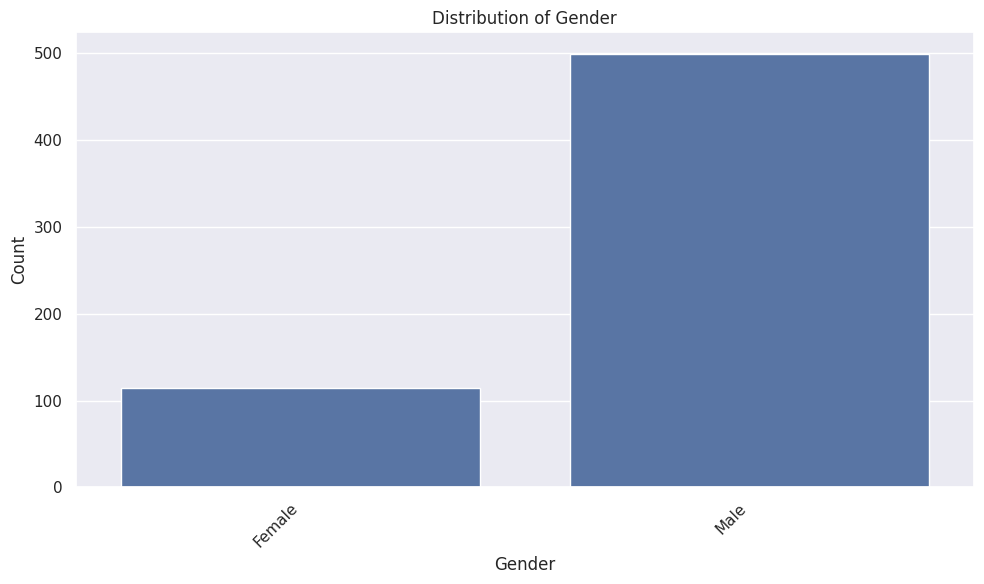

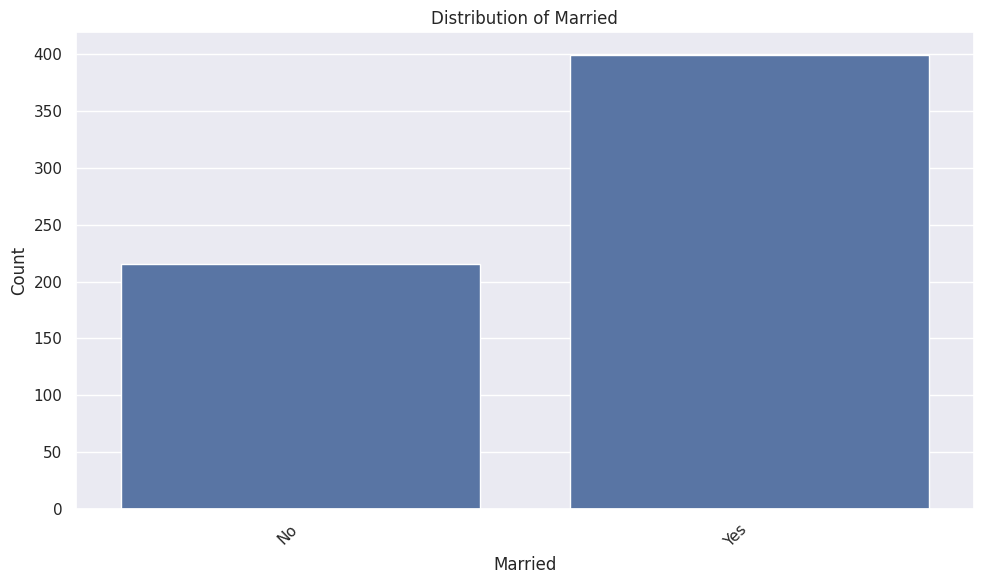

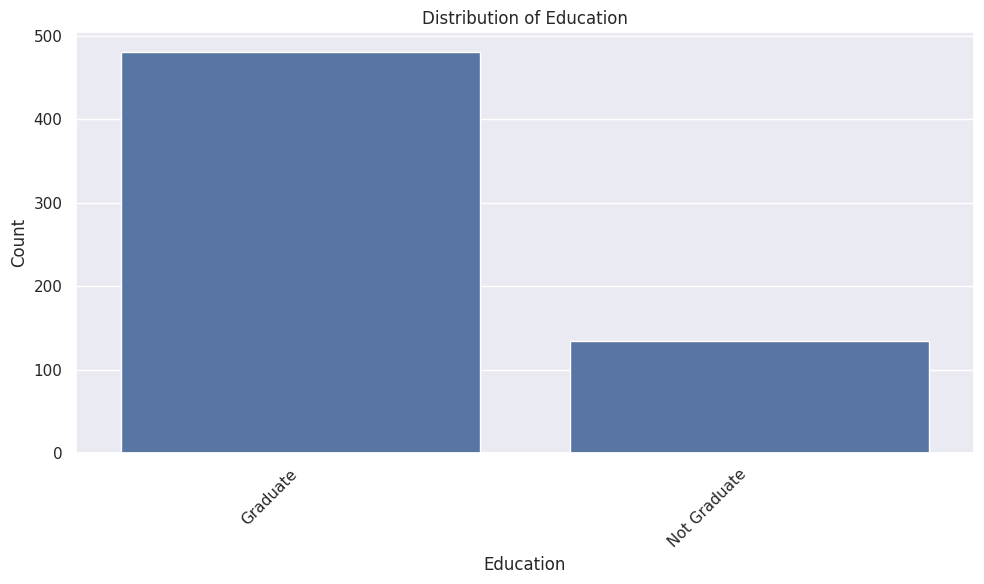

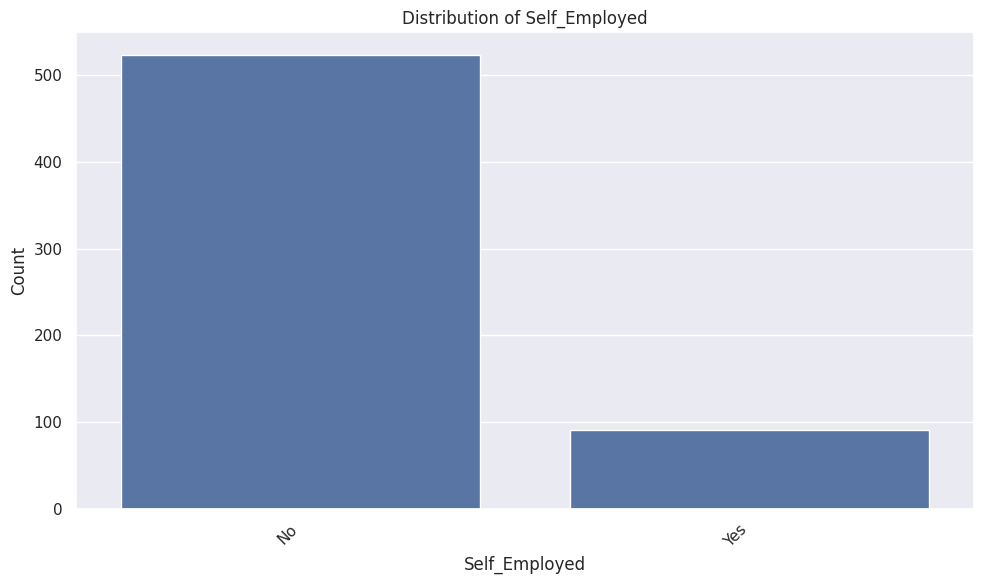

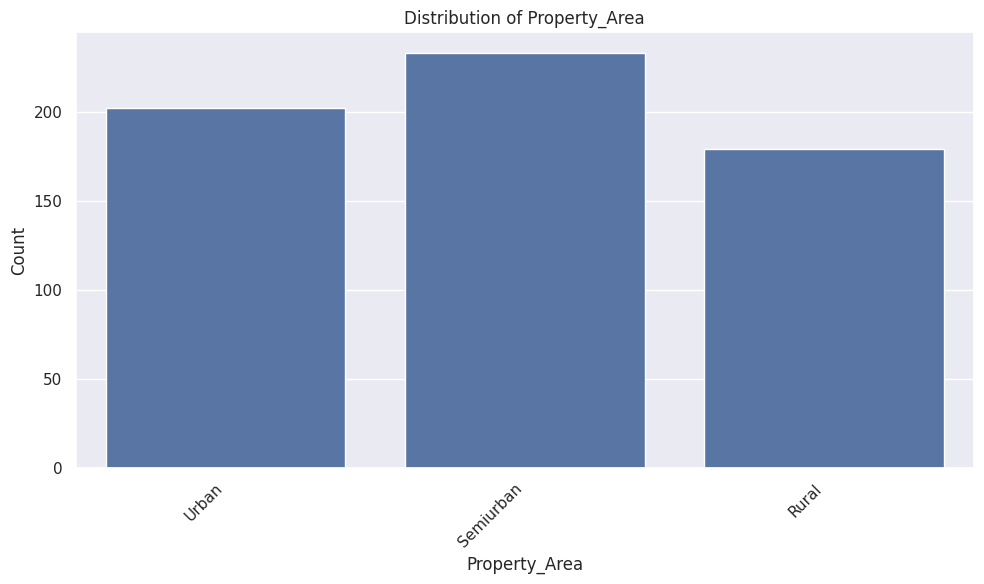

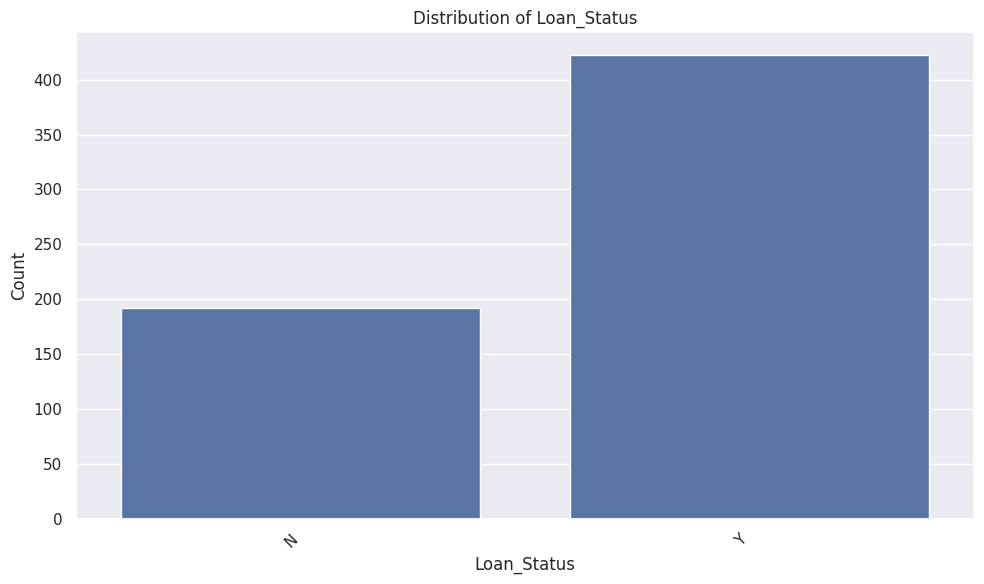

Value counts for Gender:
Gender
Male      499
Female    115
Name: count, dtype: int64

Value counts for Married:
Married
Yes    399
No     215
Name: count, dtype: int64

Value counts for Education:
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Value counts for Self_Employed:
Self_Employed
No     523
Yes     91
Name: count, dtype: int64

Value counts for Property_Area:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Value counts for Loan_Status:
Loan_Status
Y    422
N    192
Name: count, dtype: int64



In [19]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

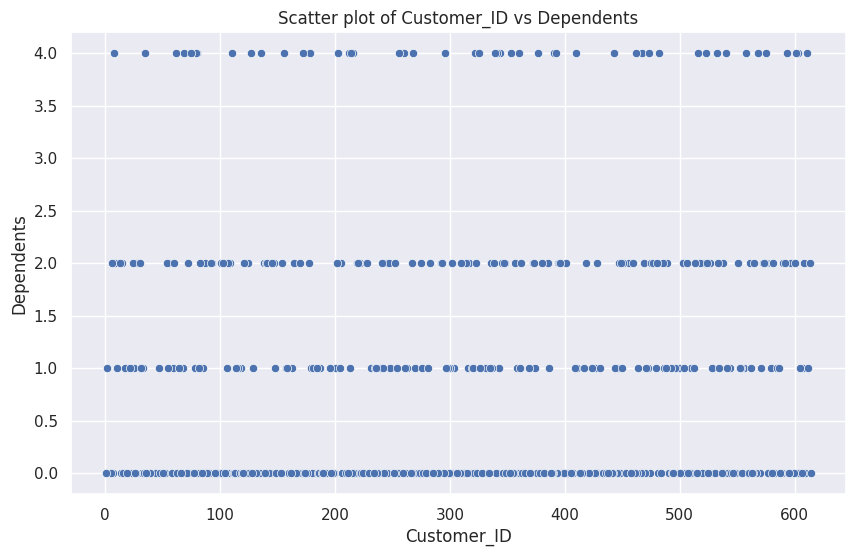

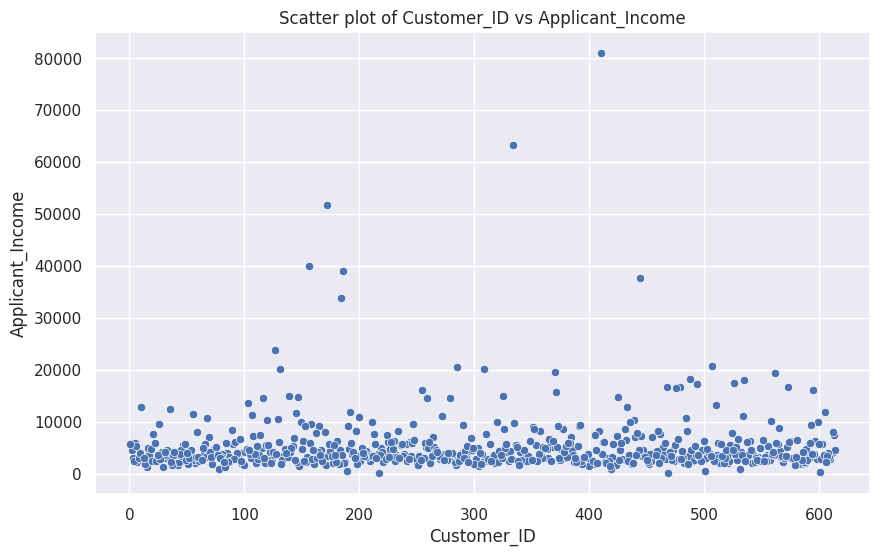

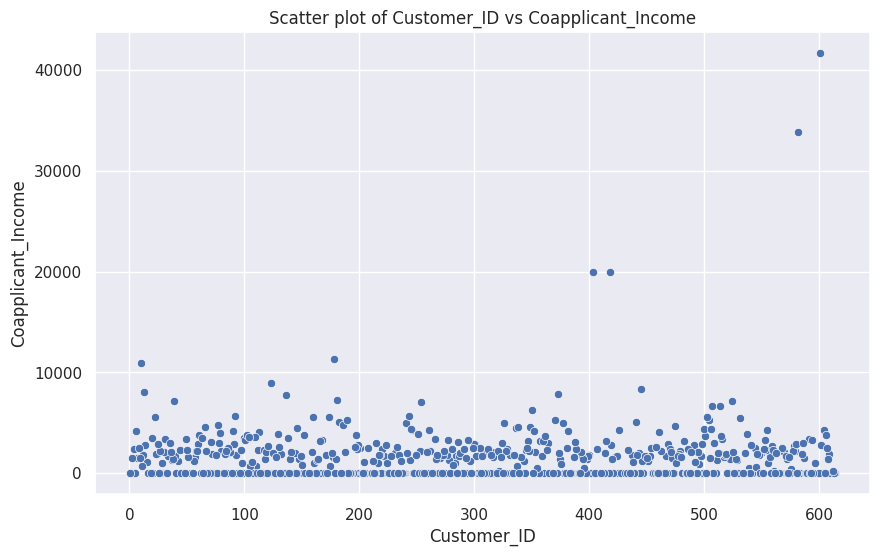

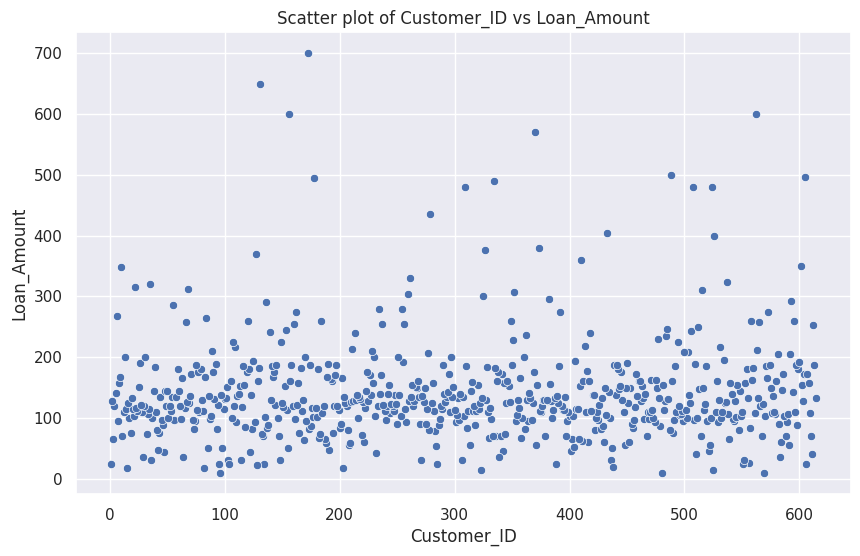

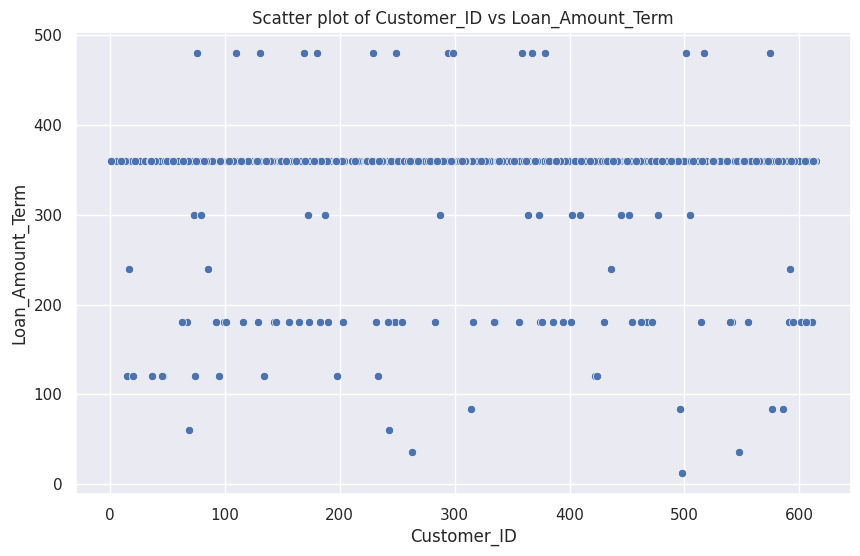

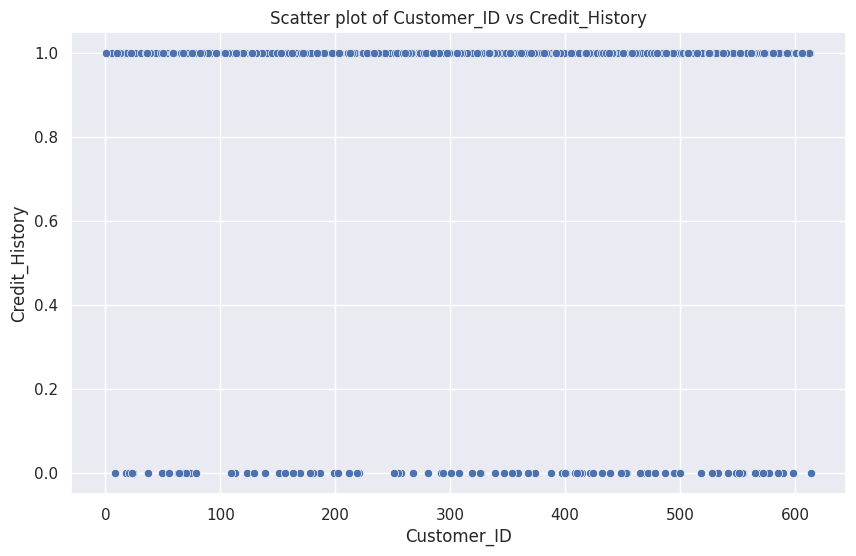

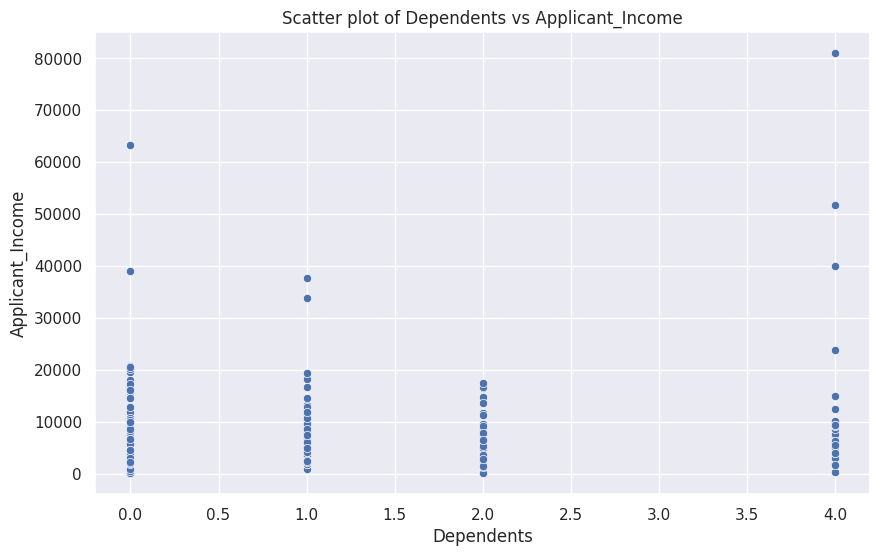

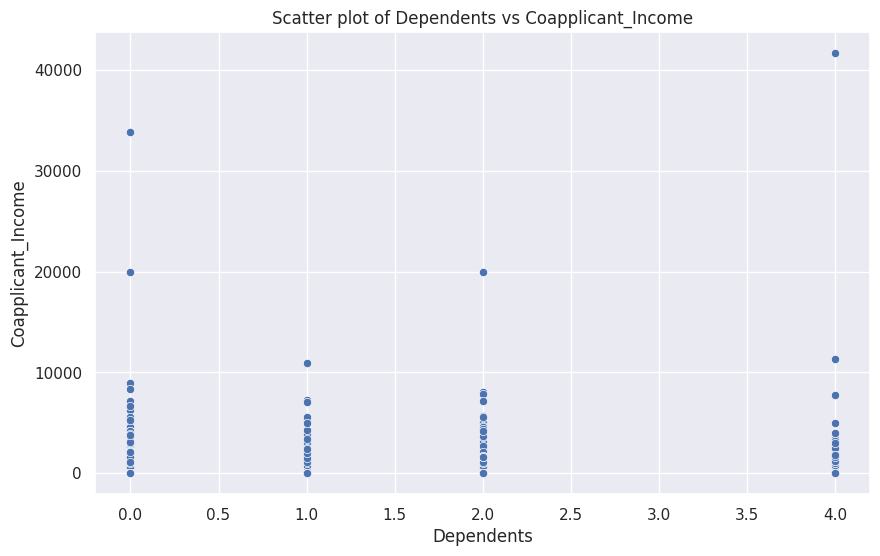

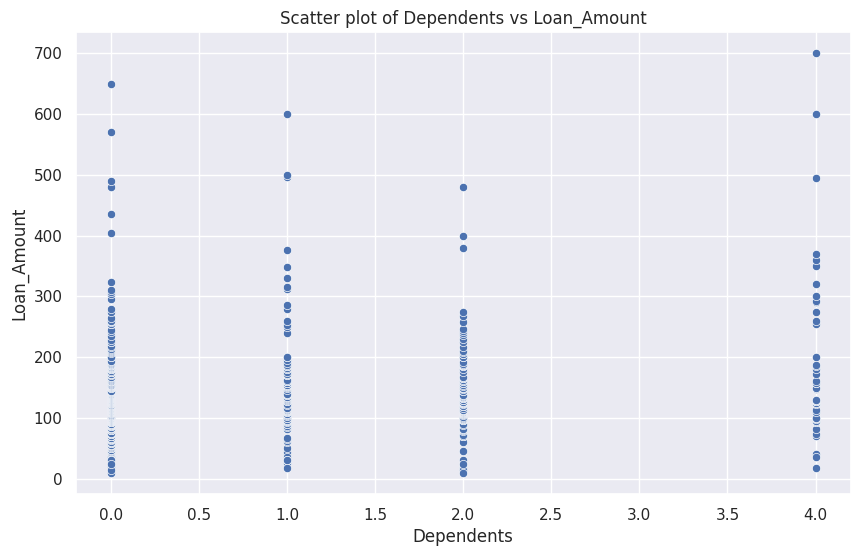

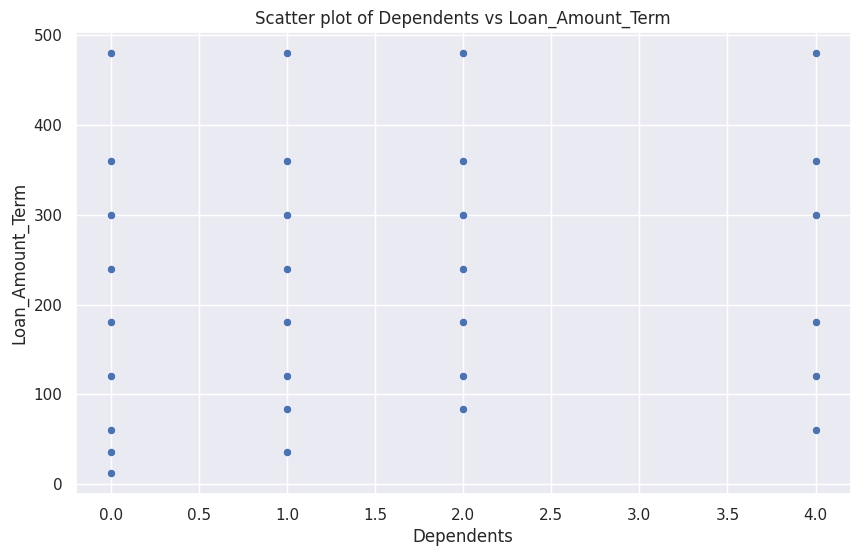

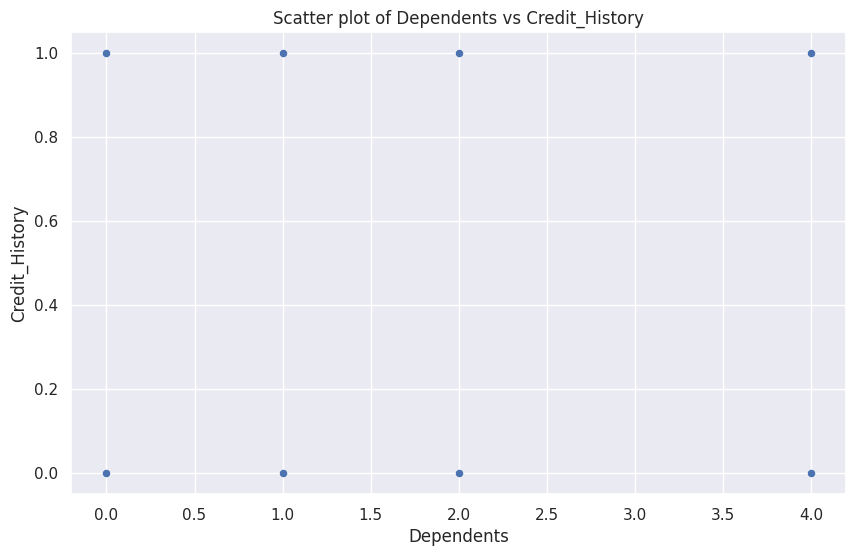

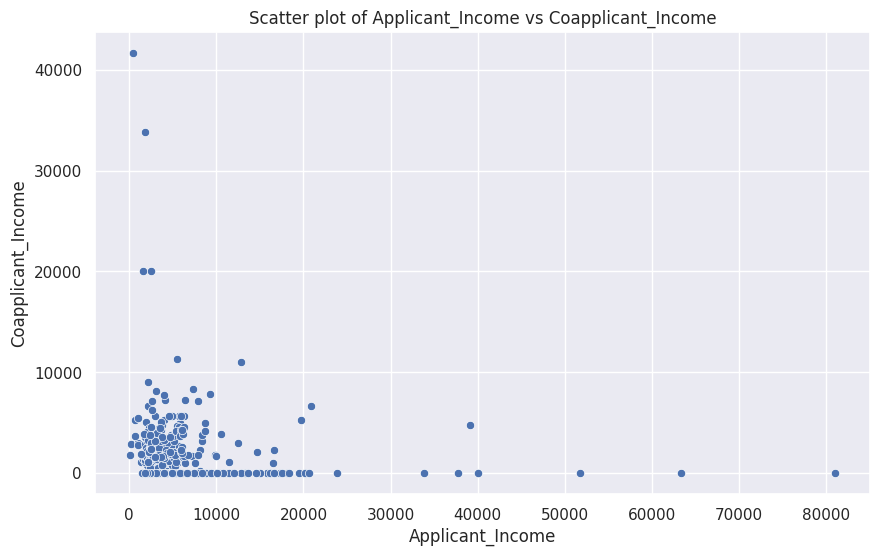

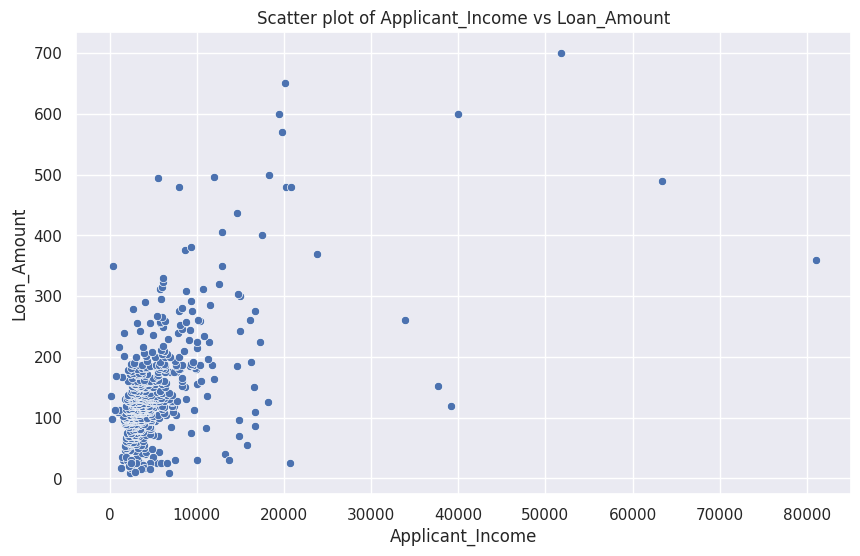

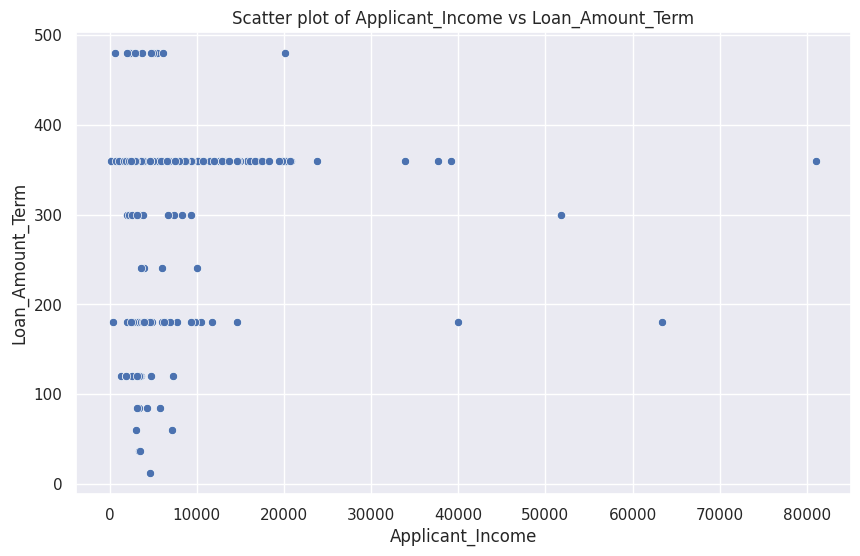

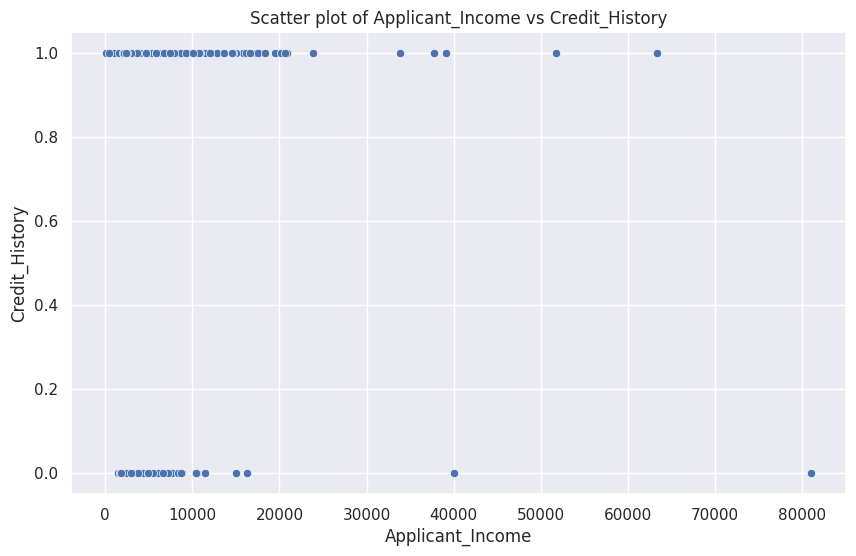

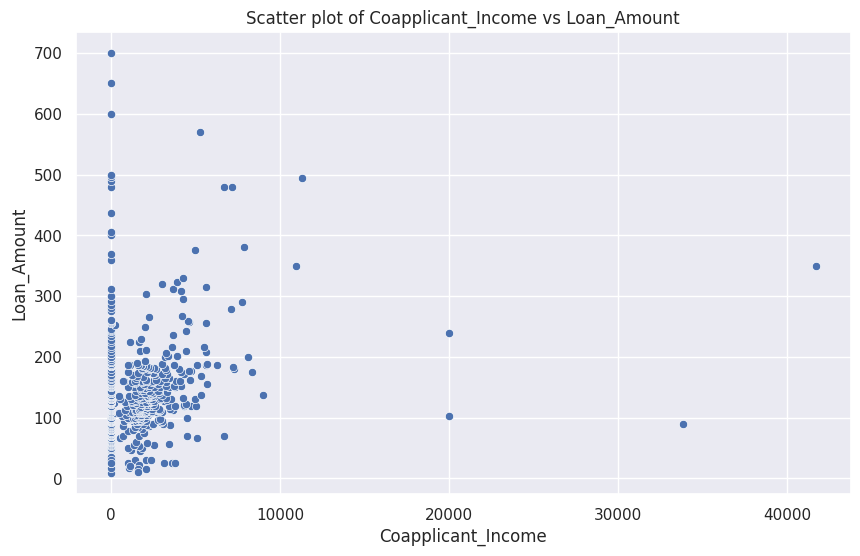

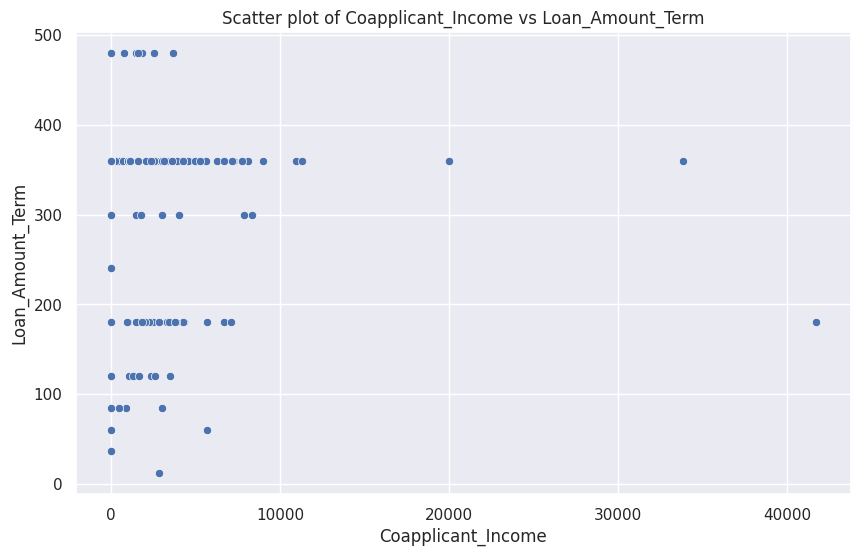

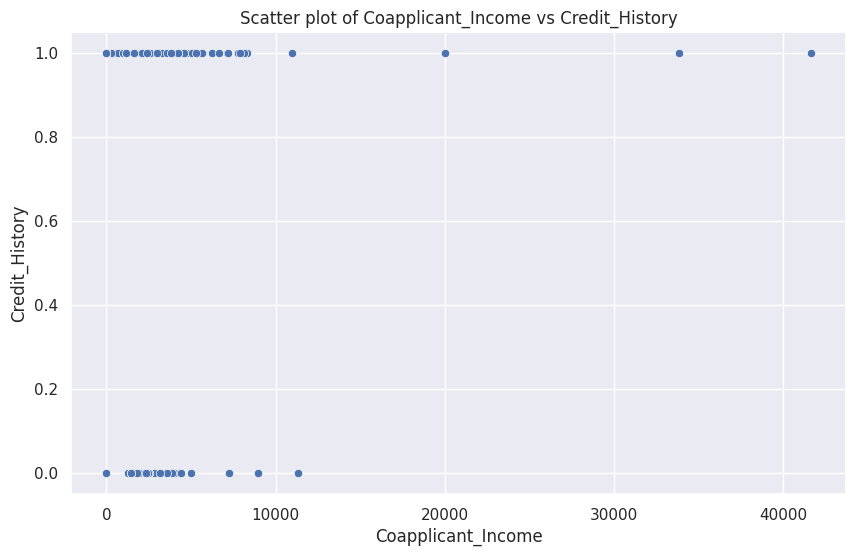

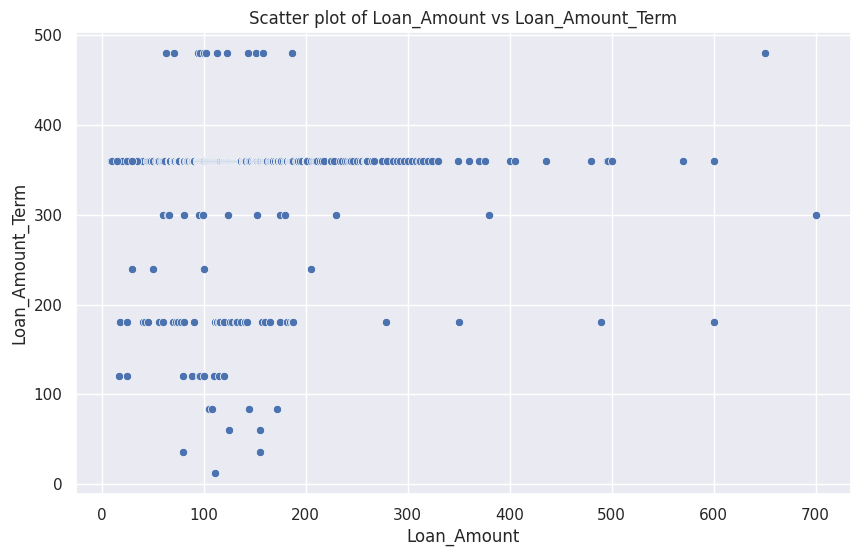

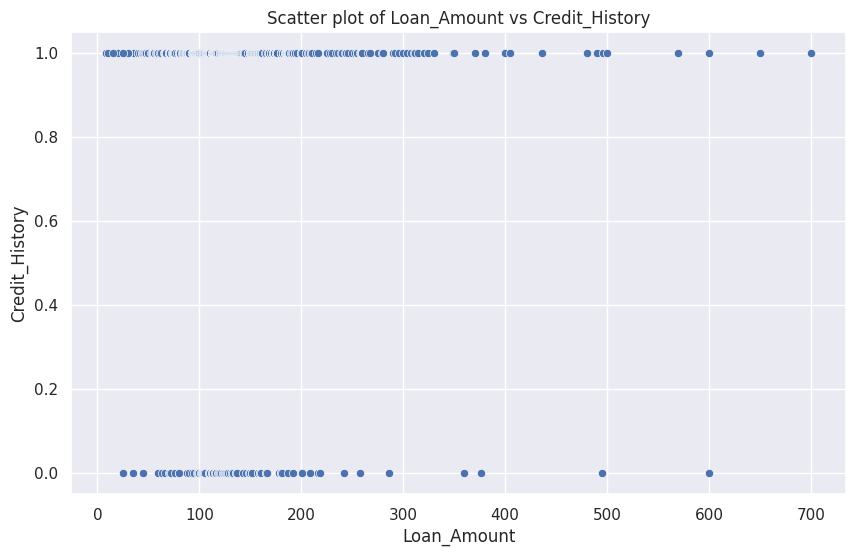

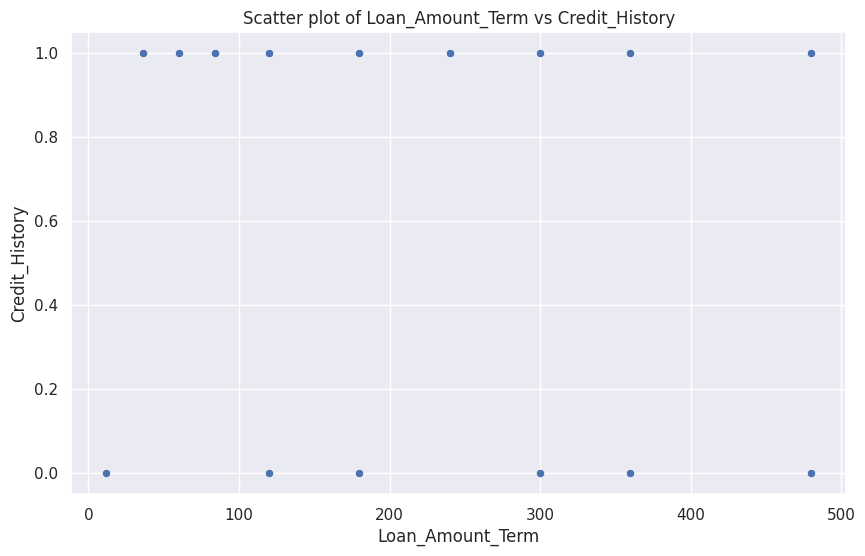

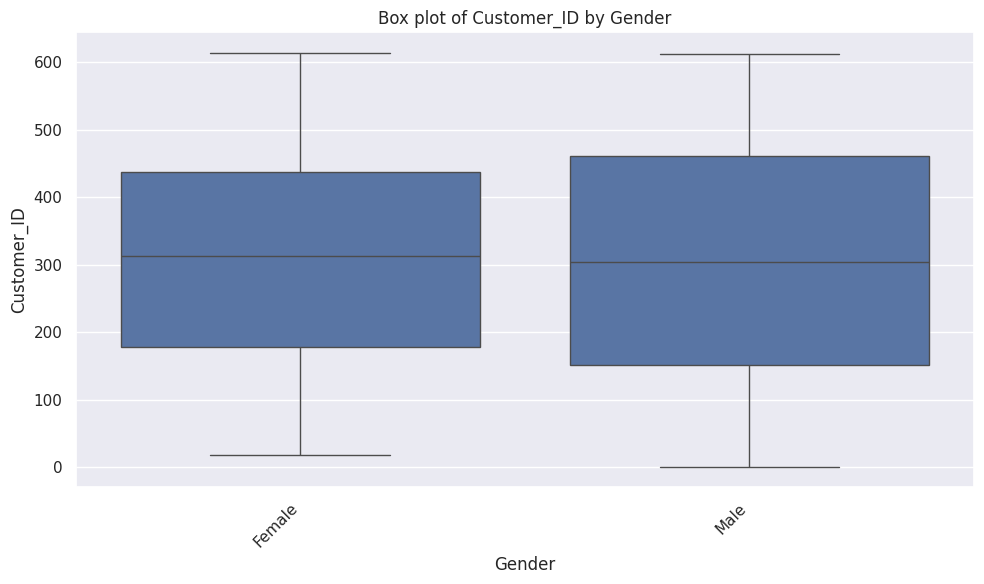

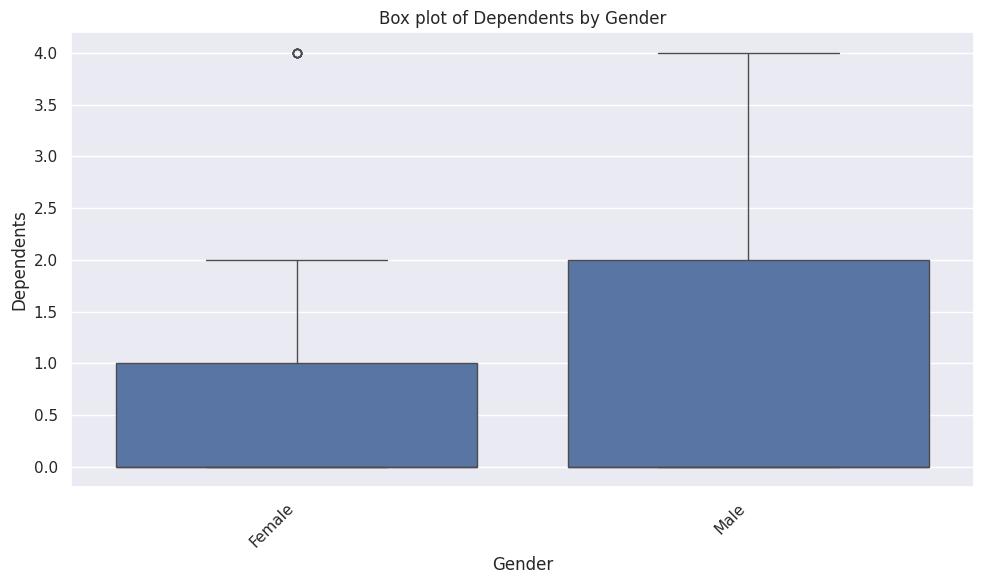

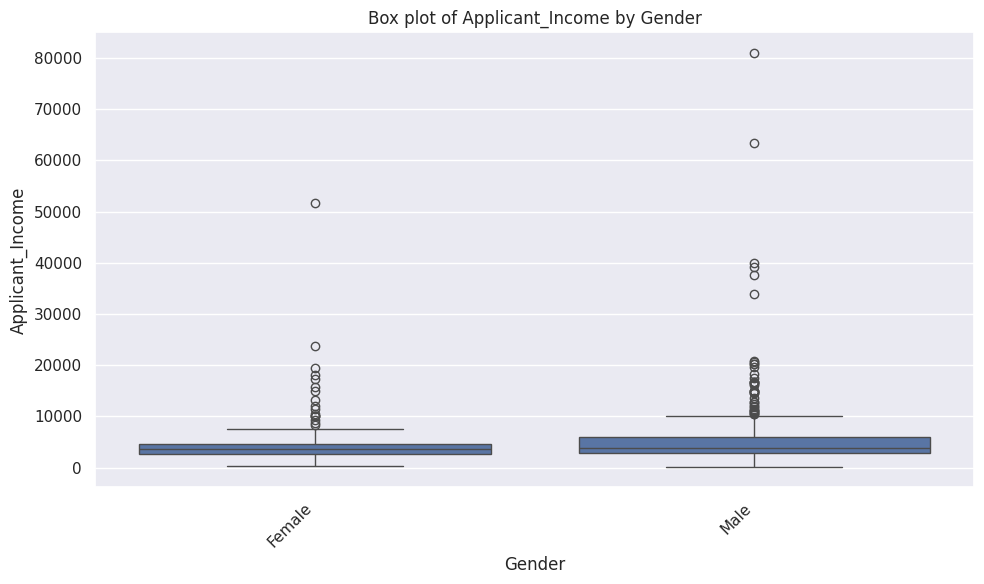

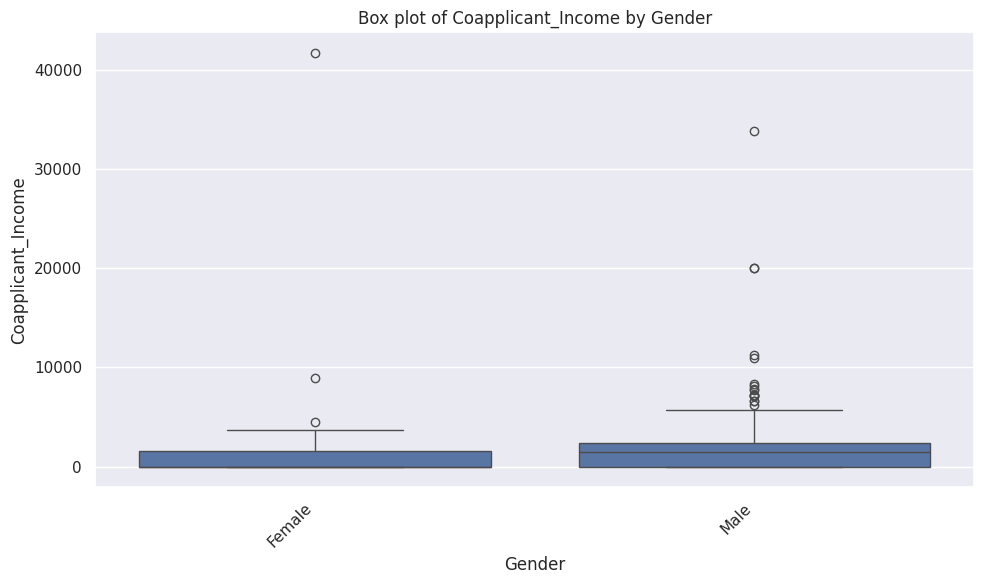

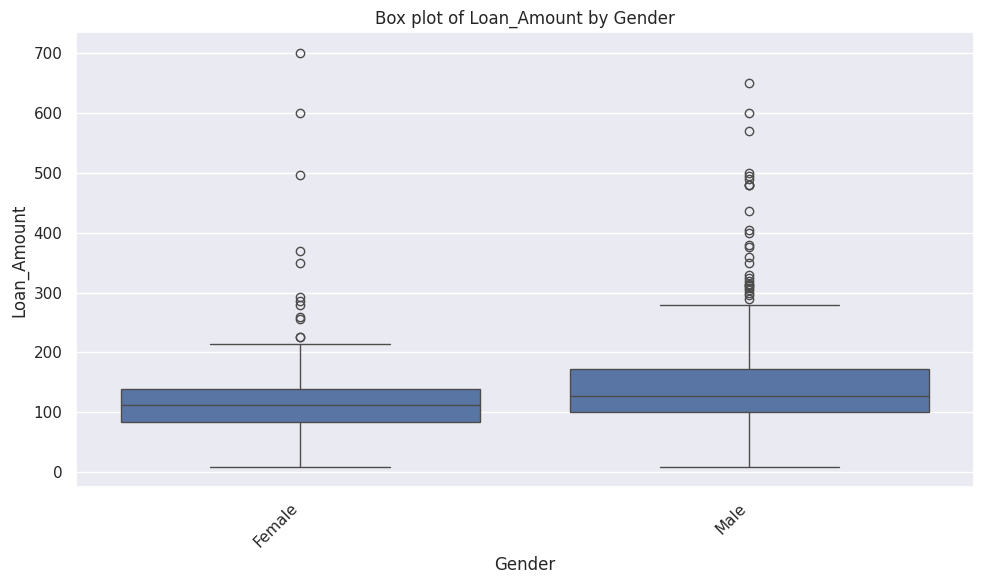

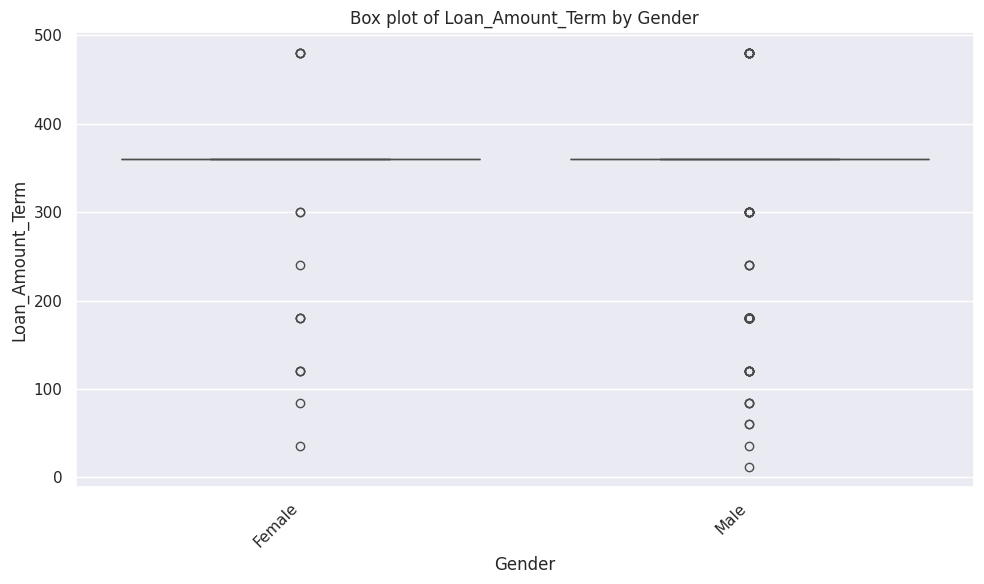

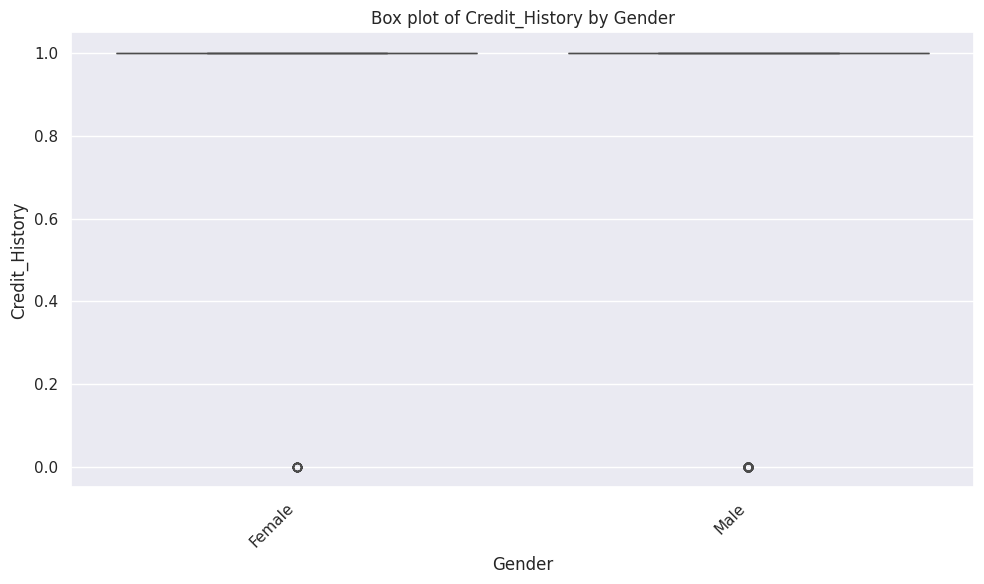

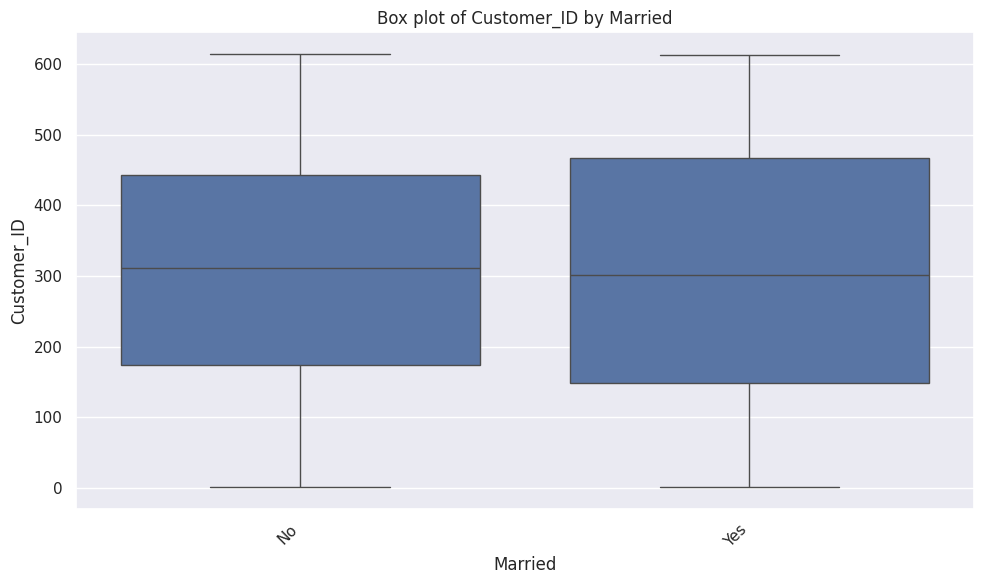

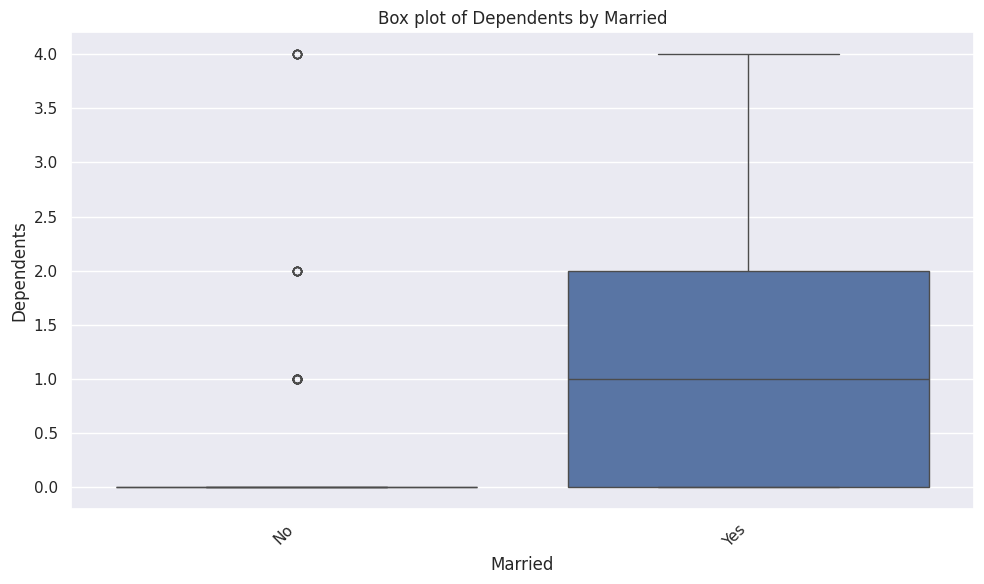

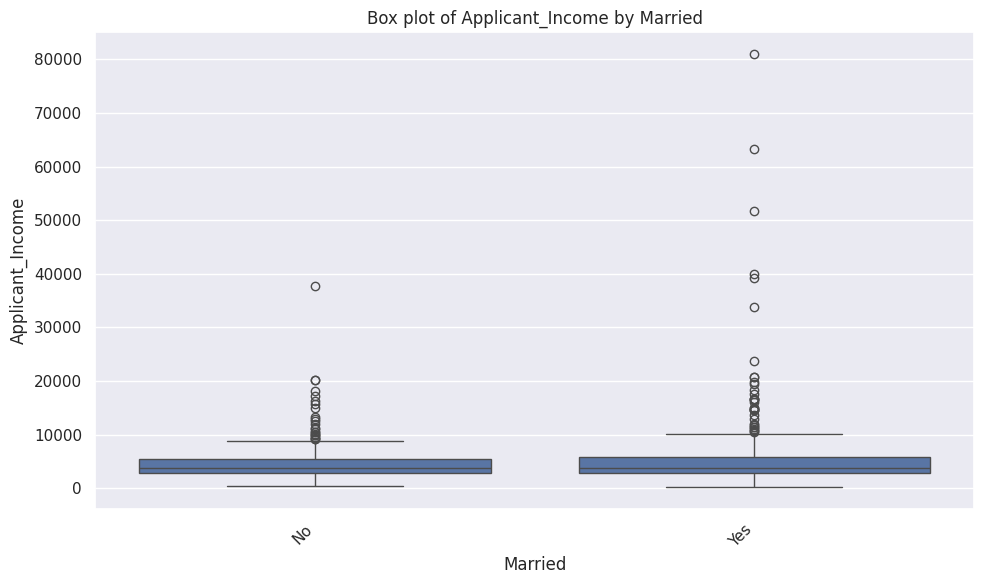

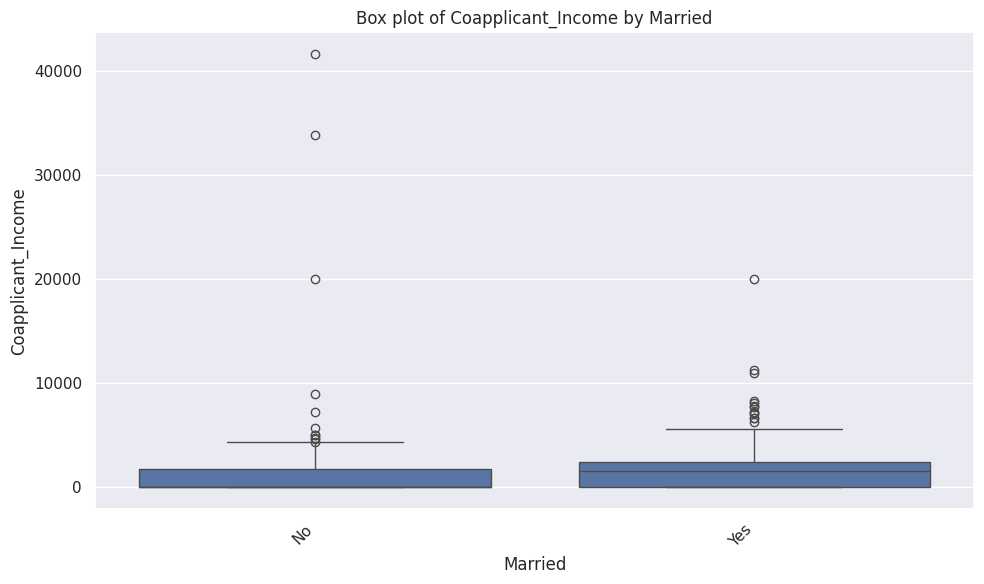

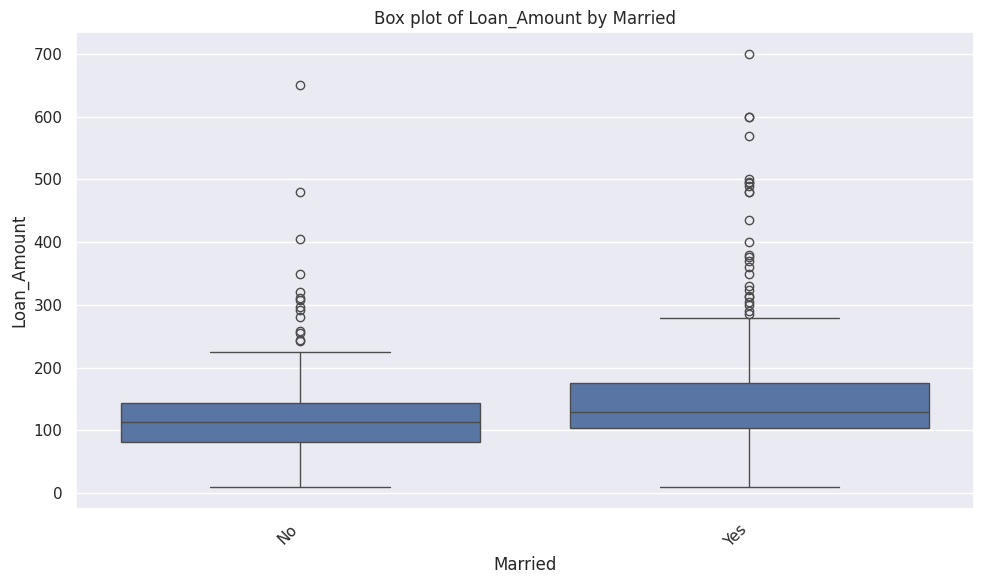

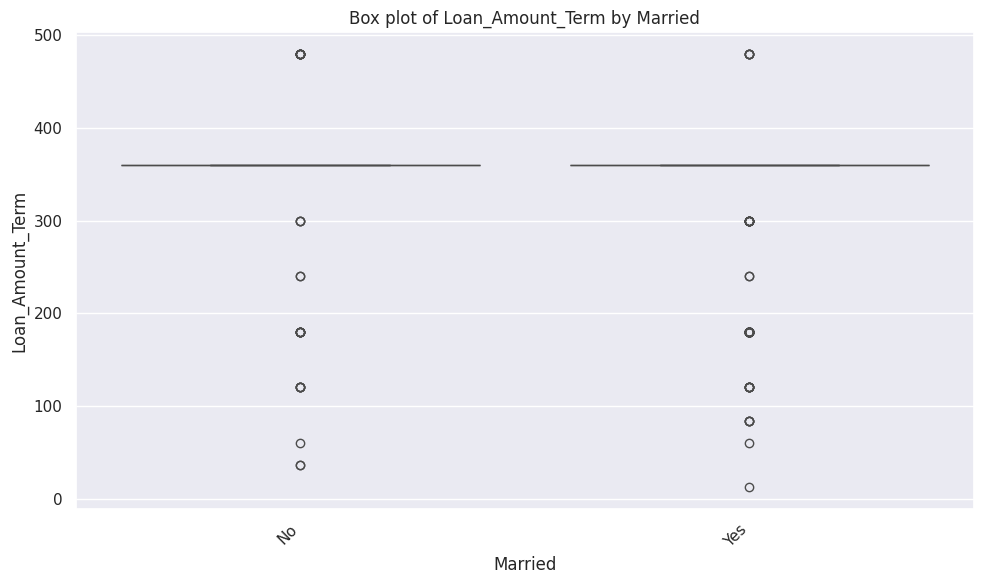

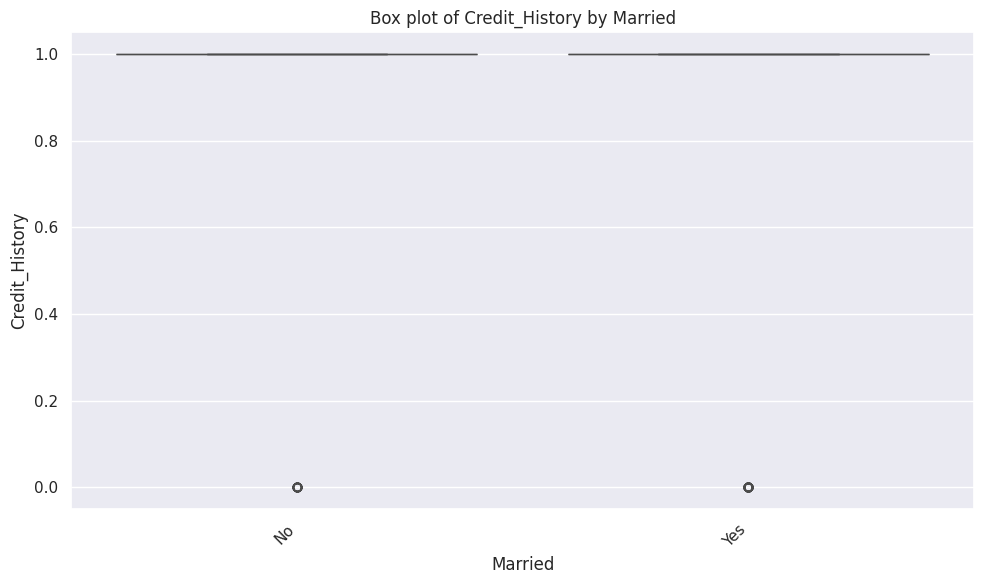

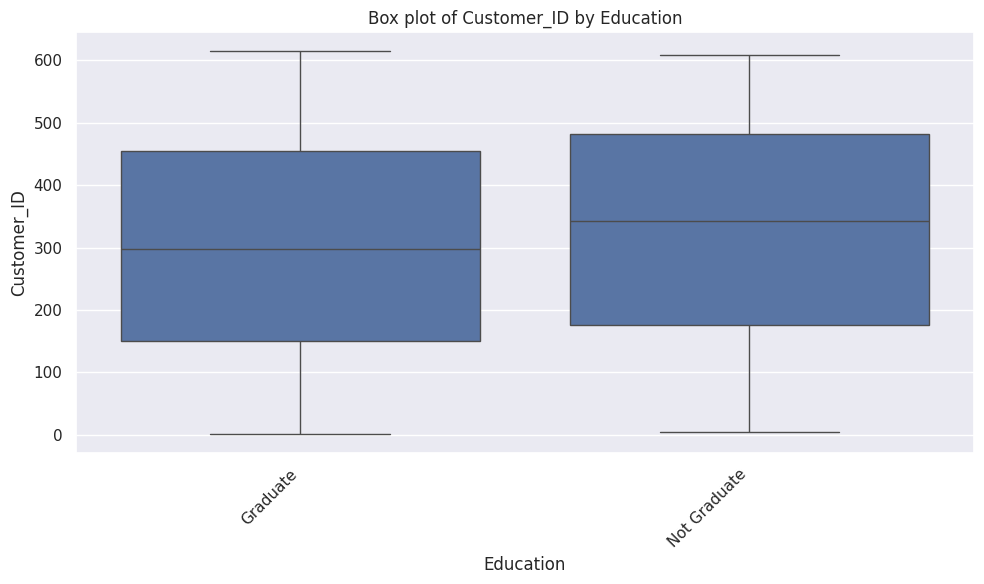

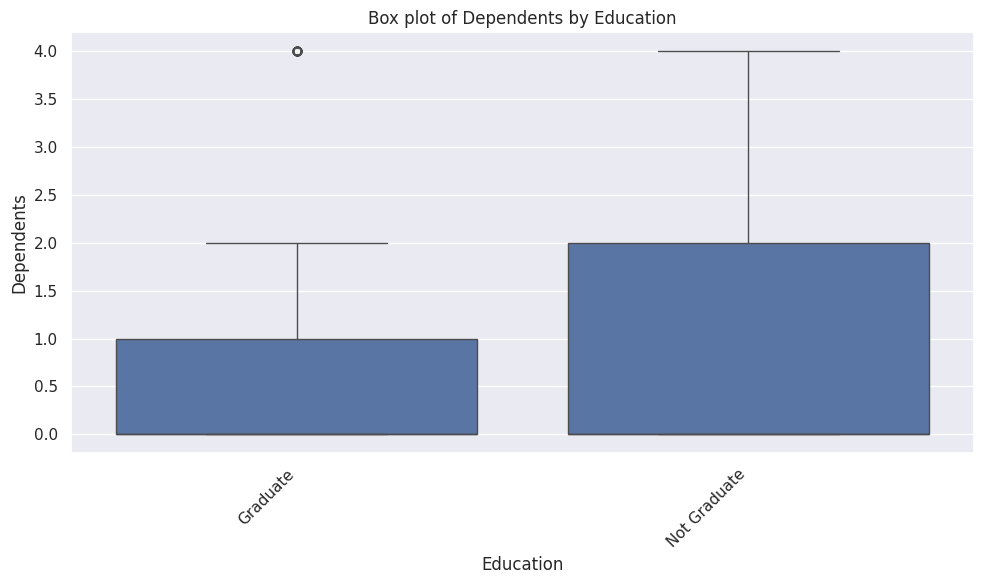

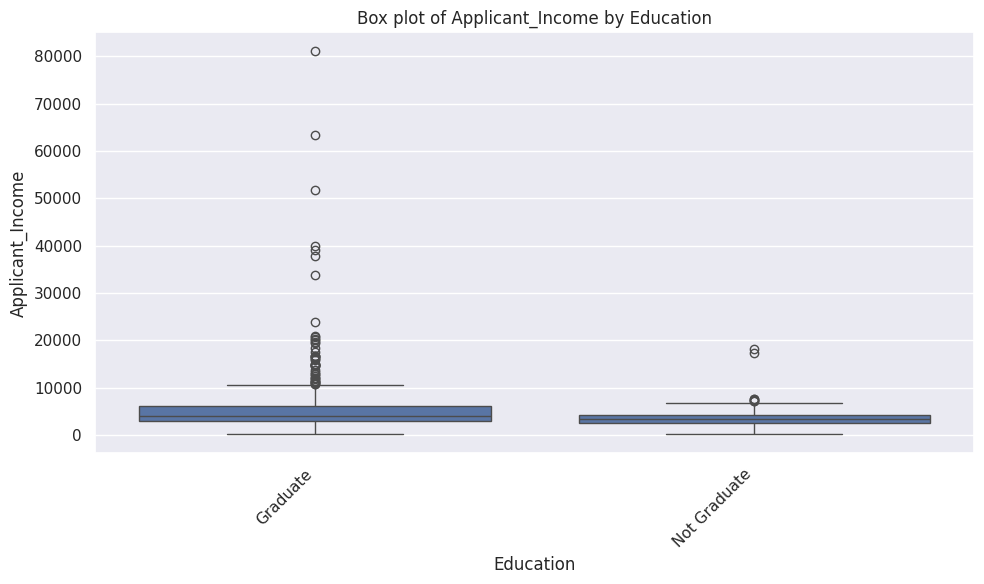

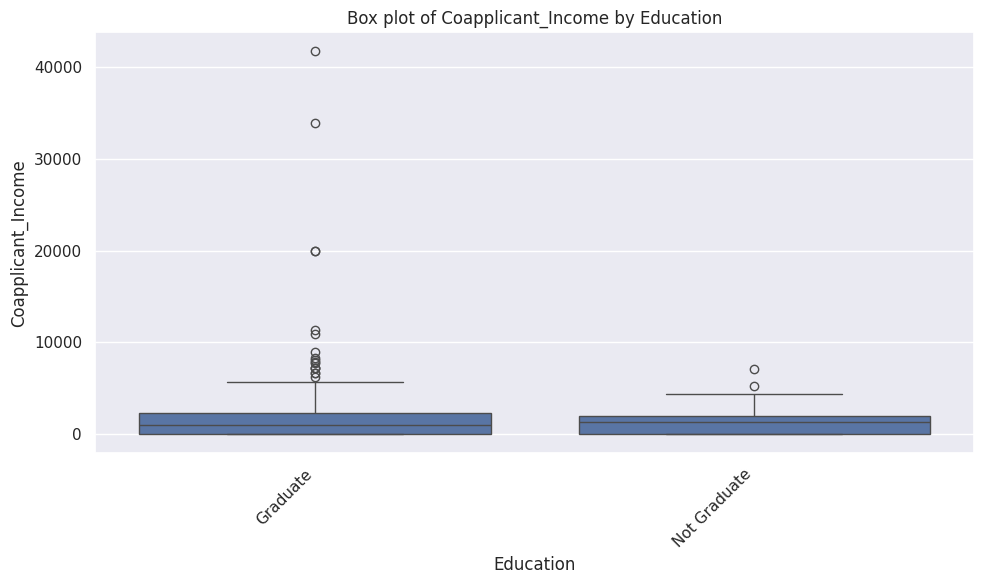

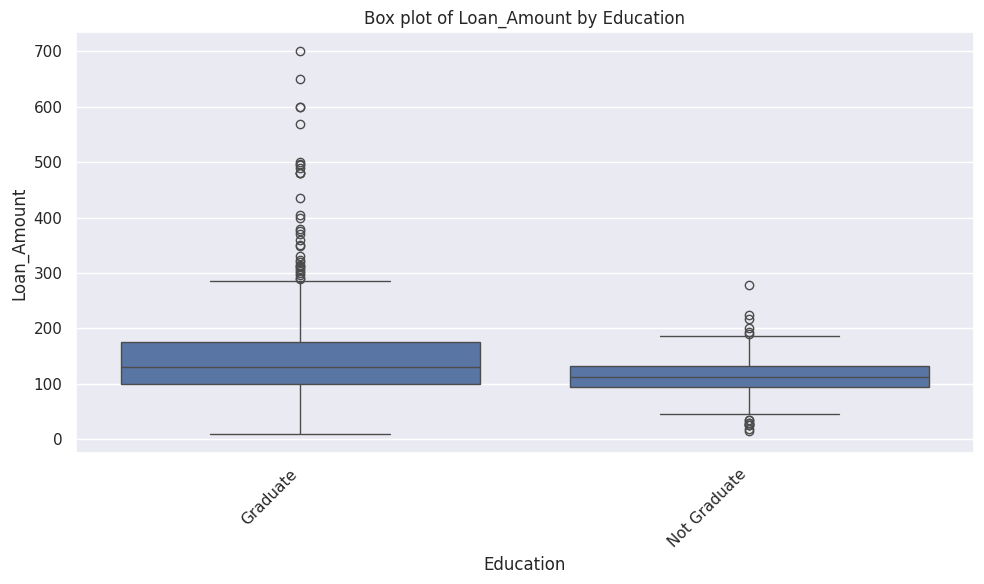

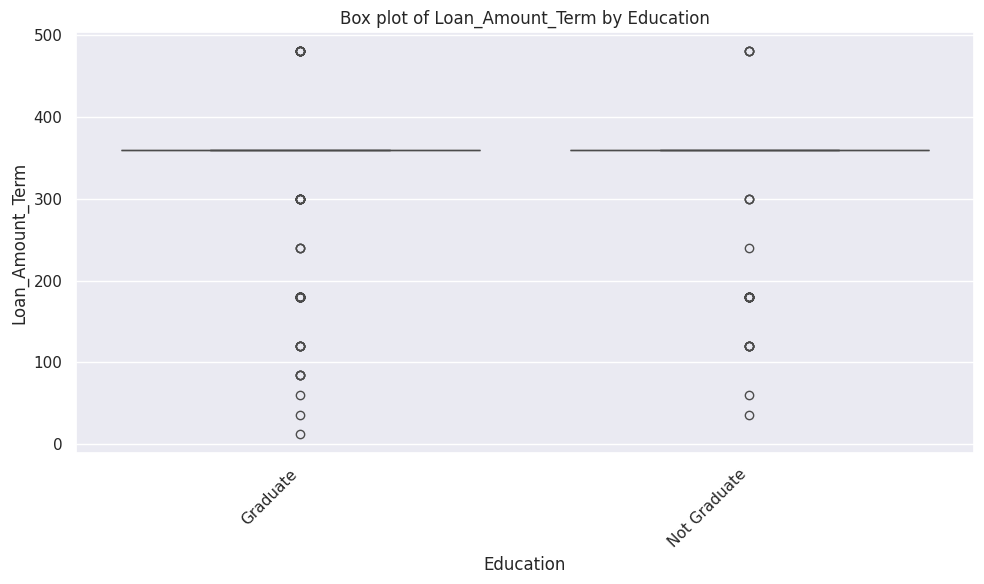

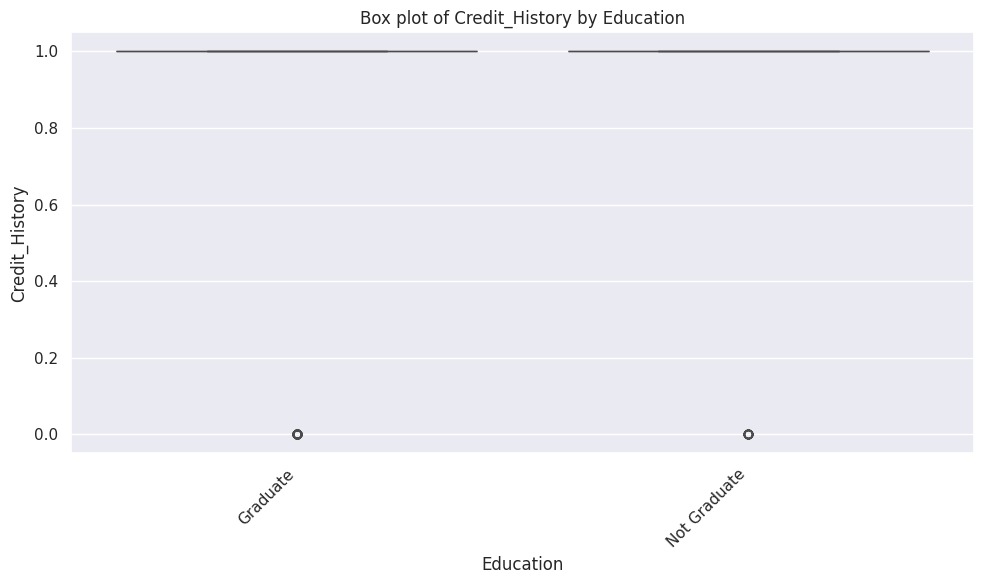

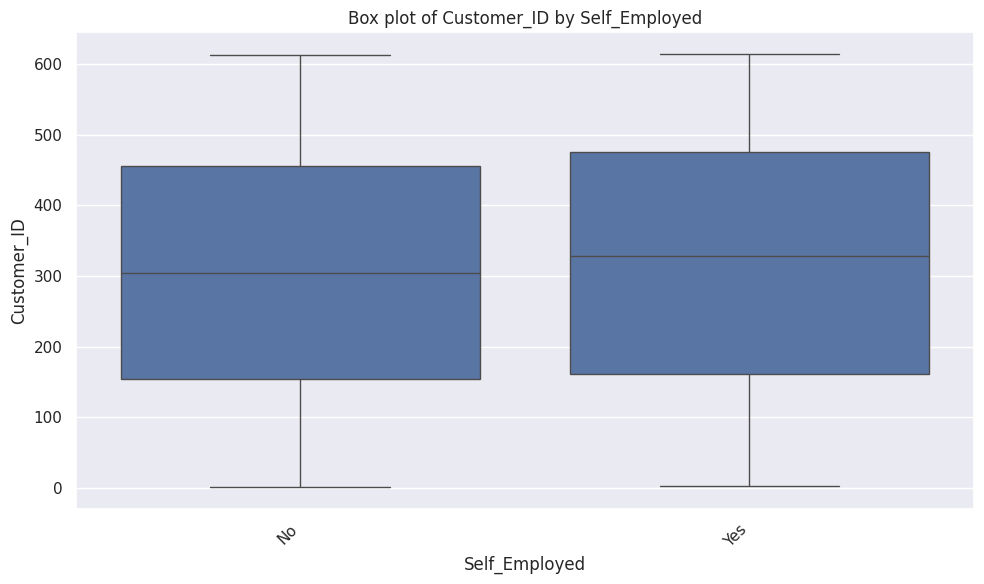

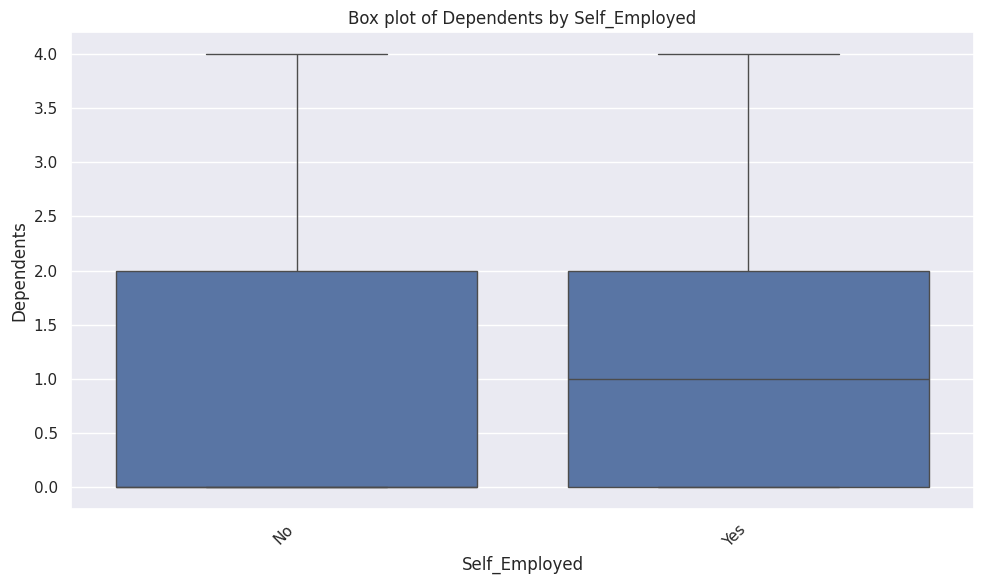

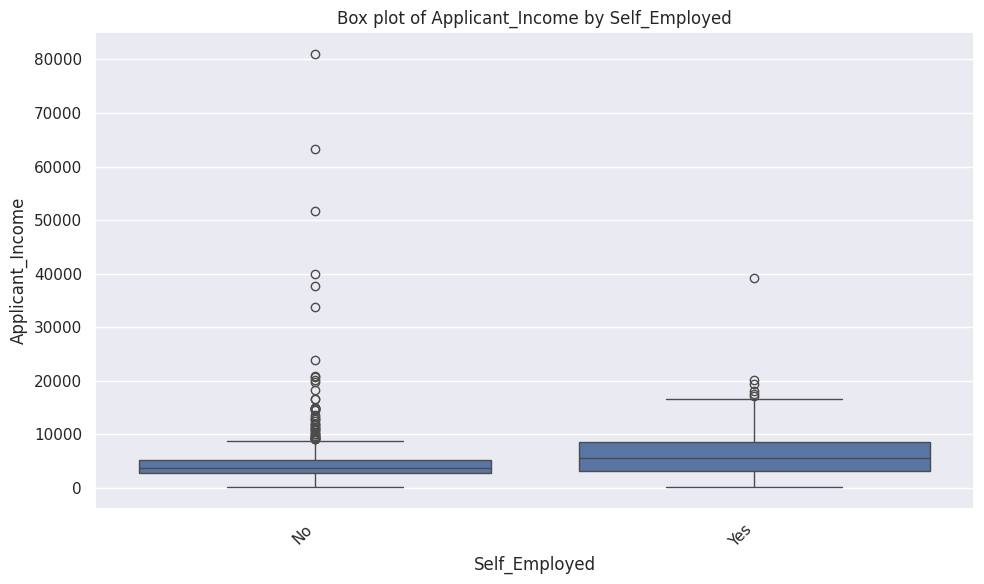

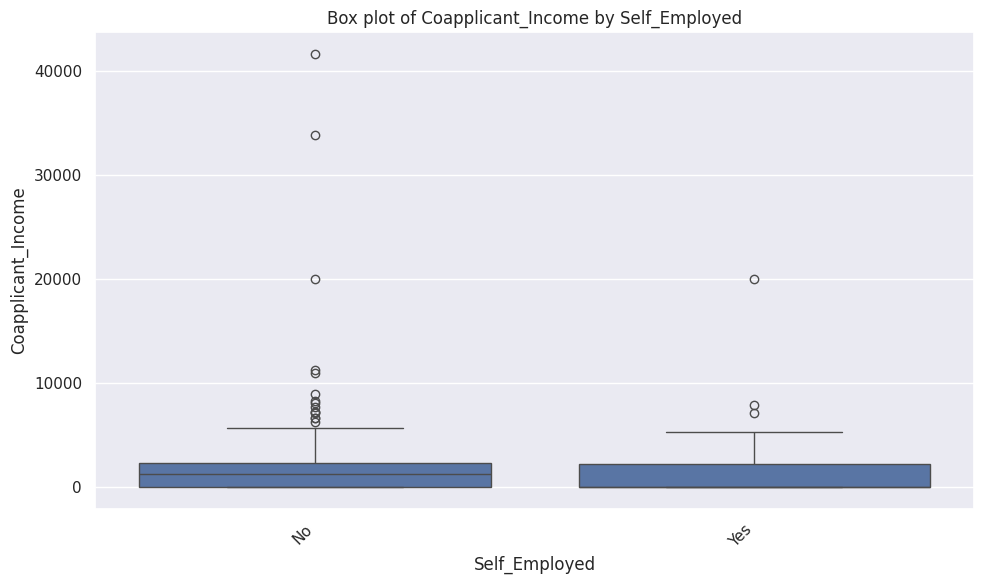

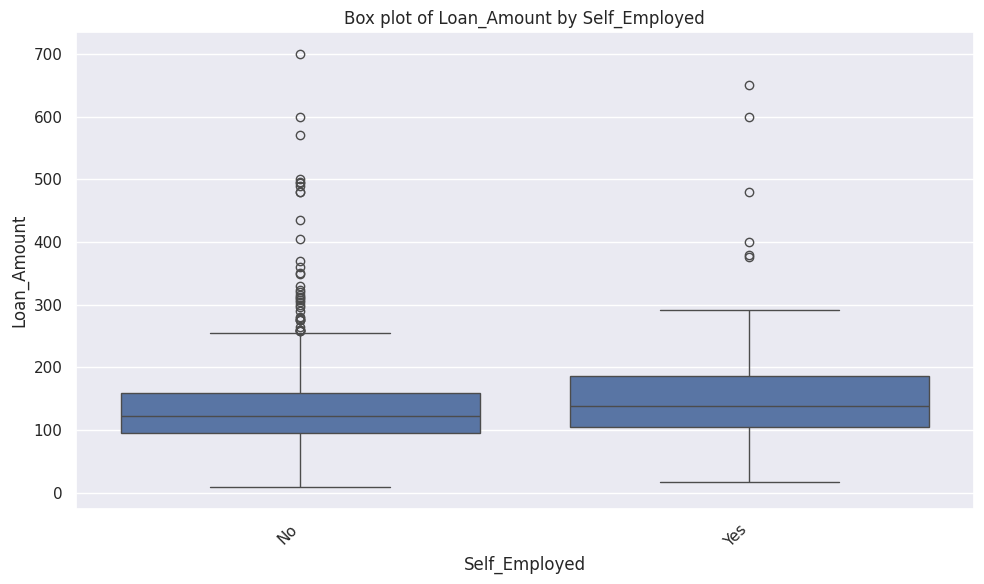

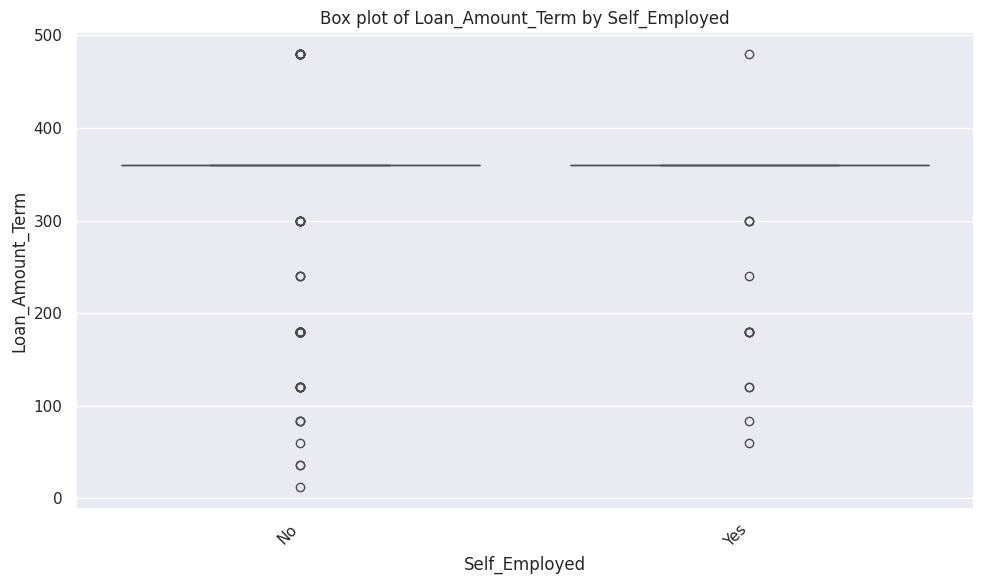

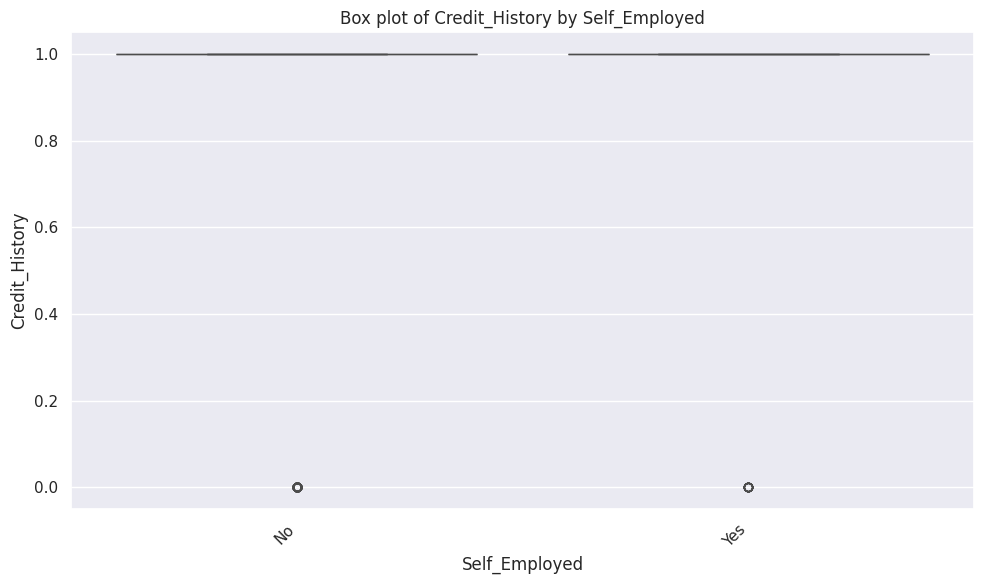

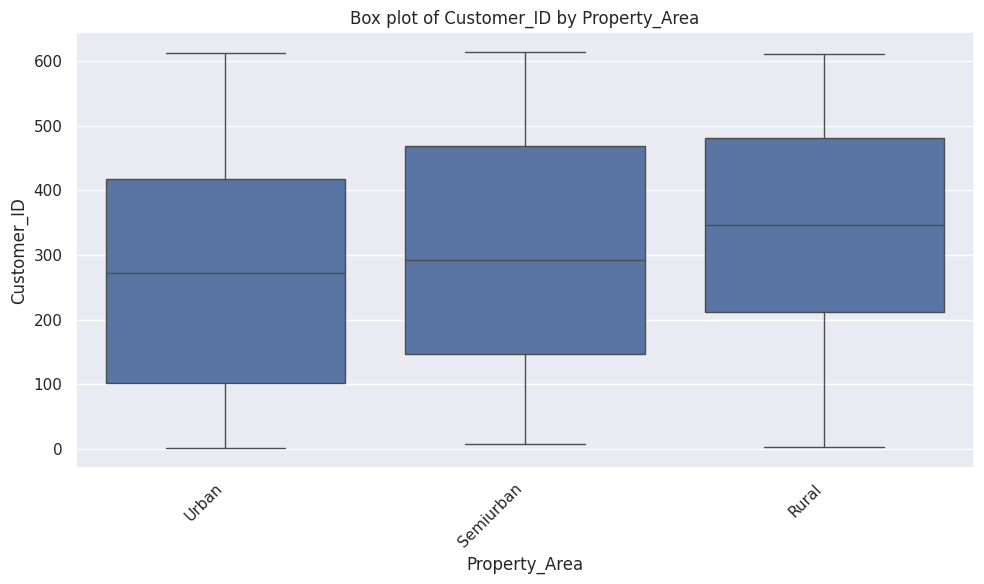

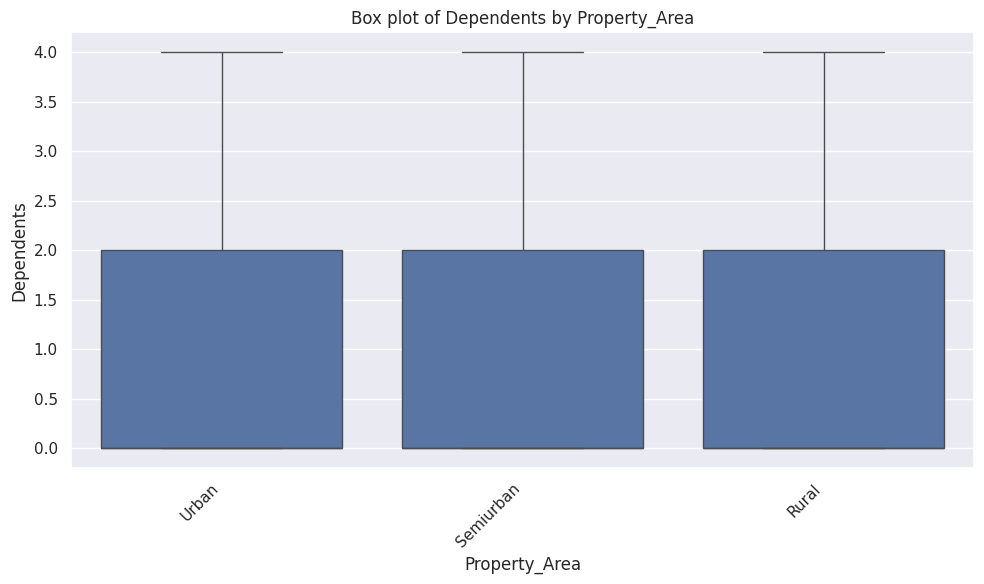

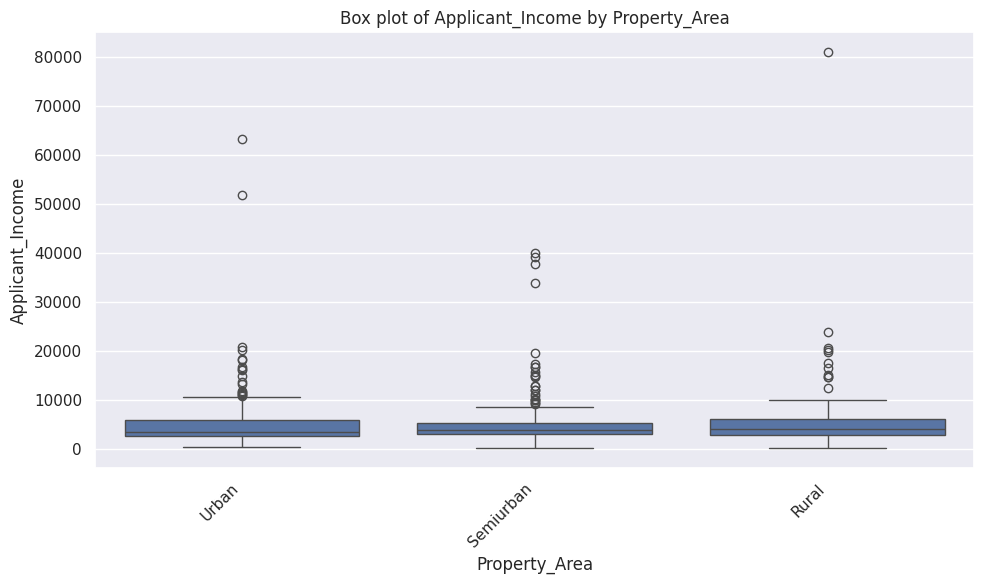

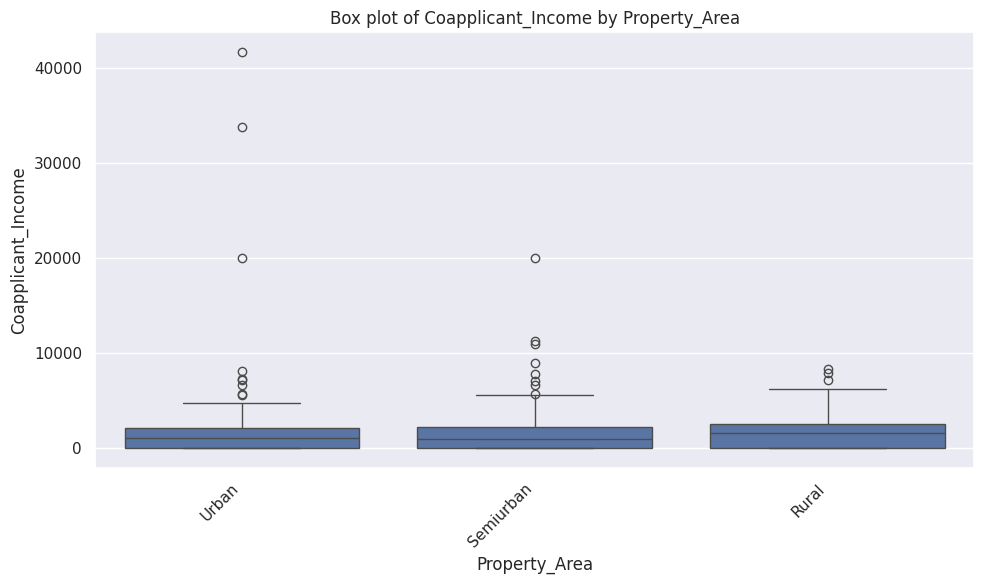

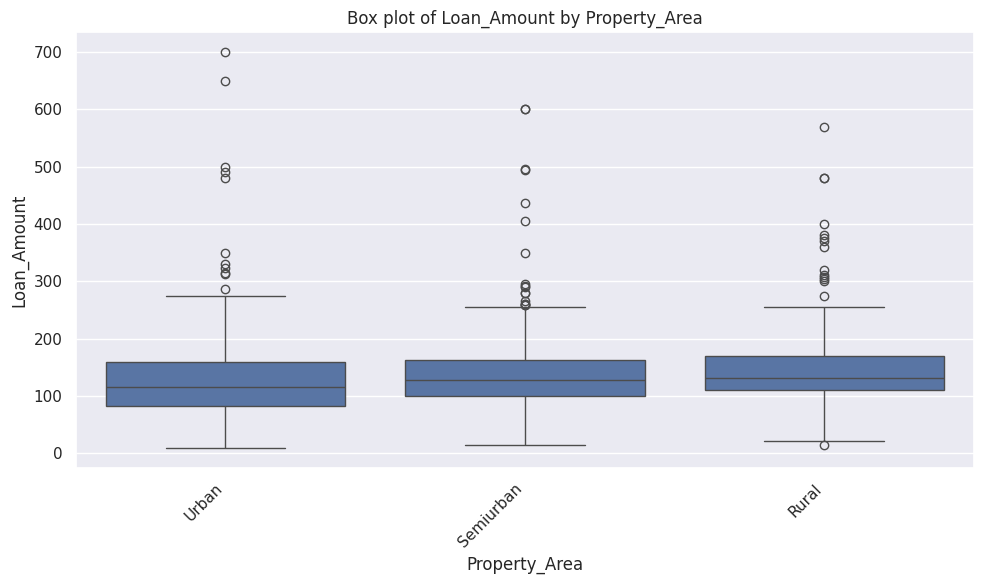

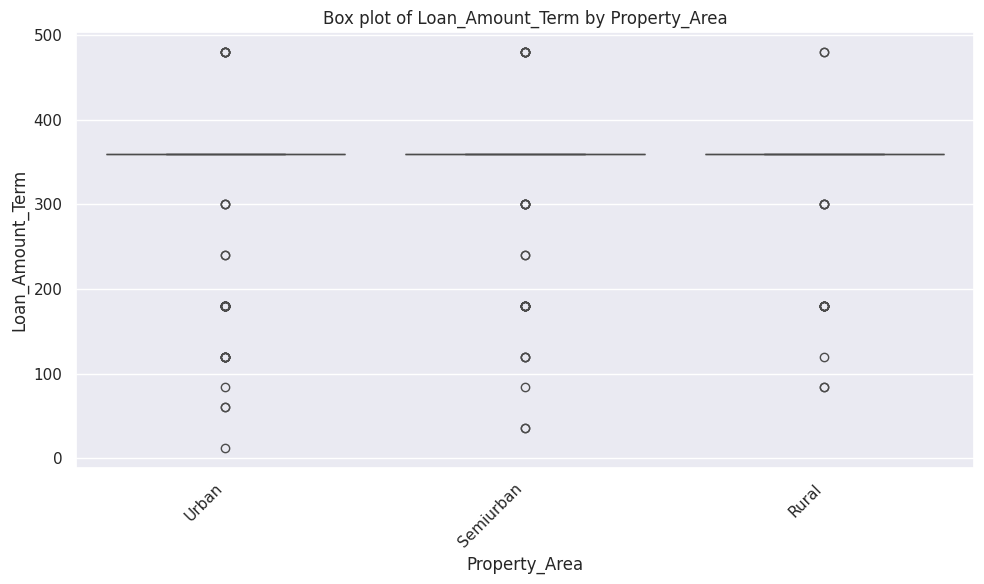

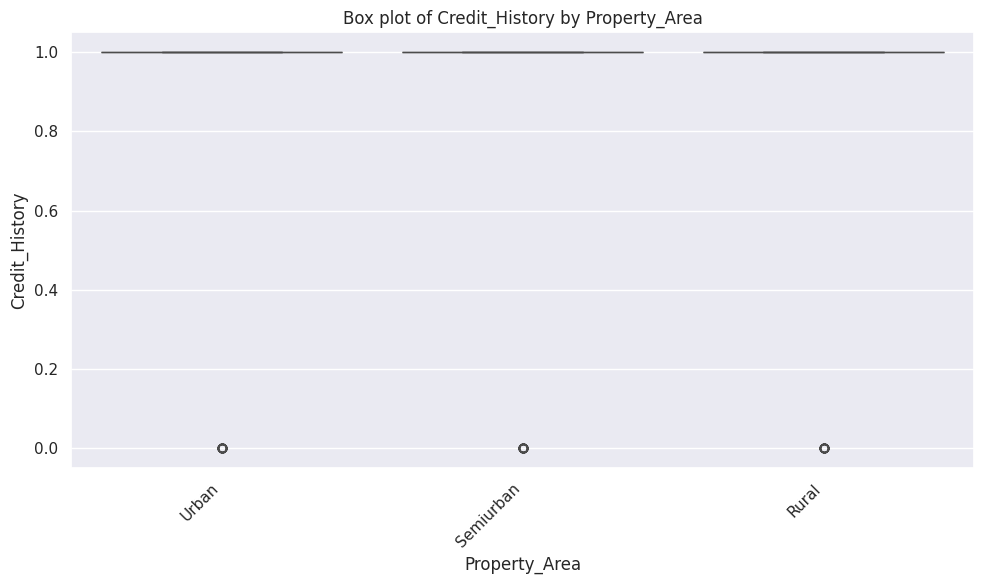

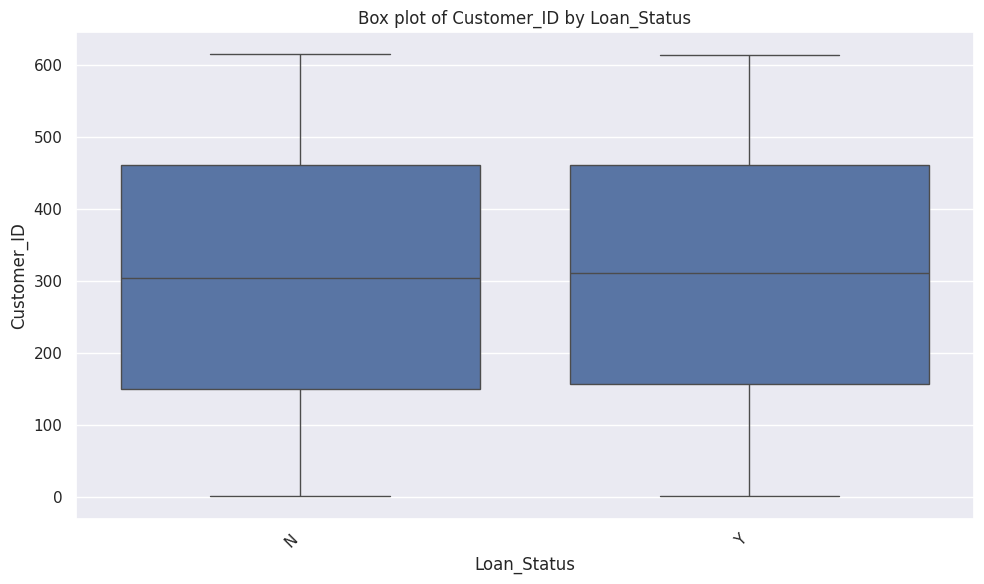

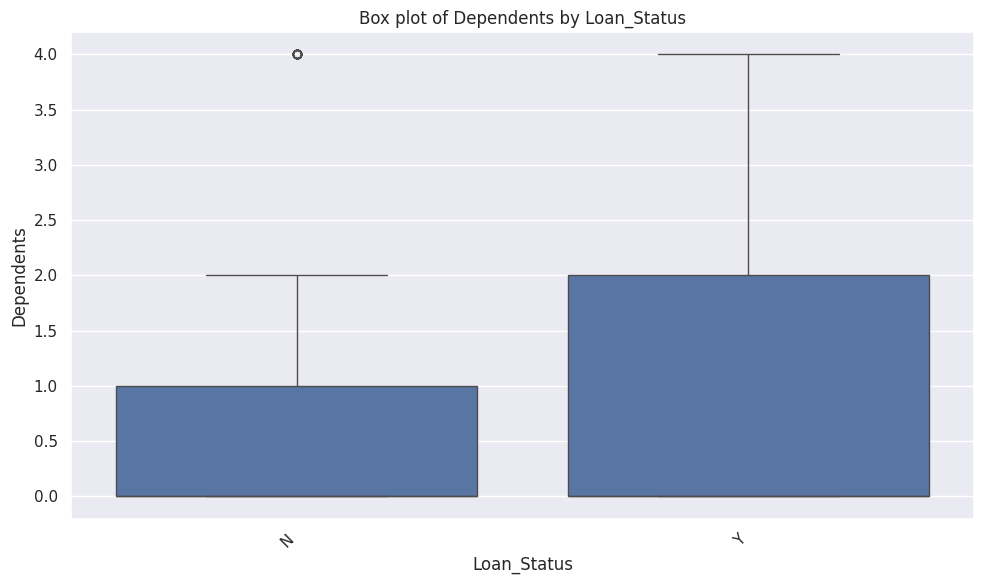

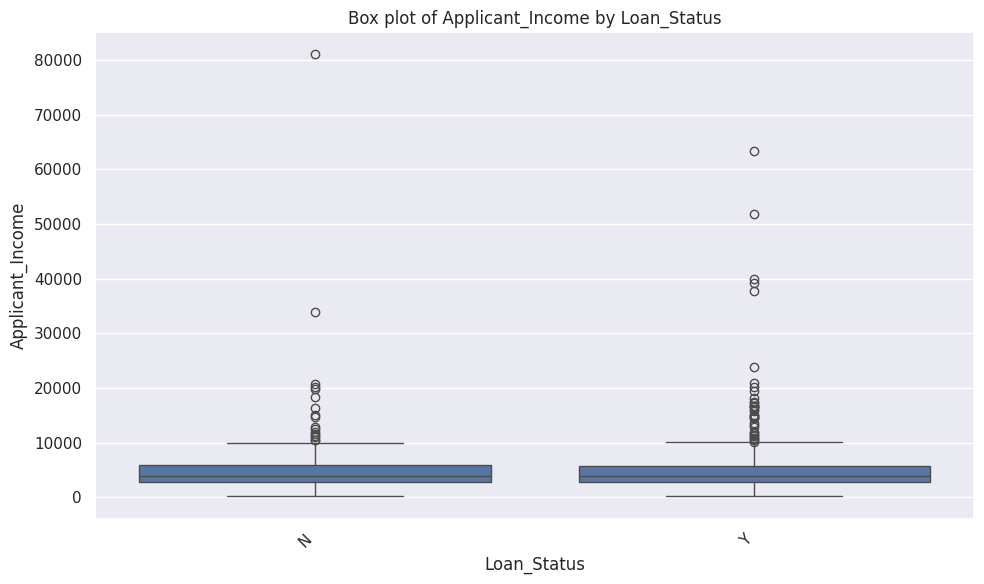

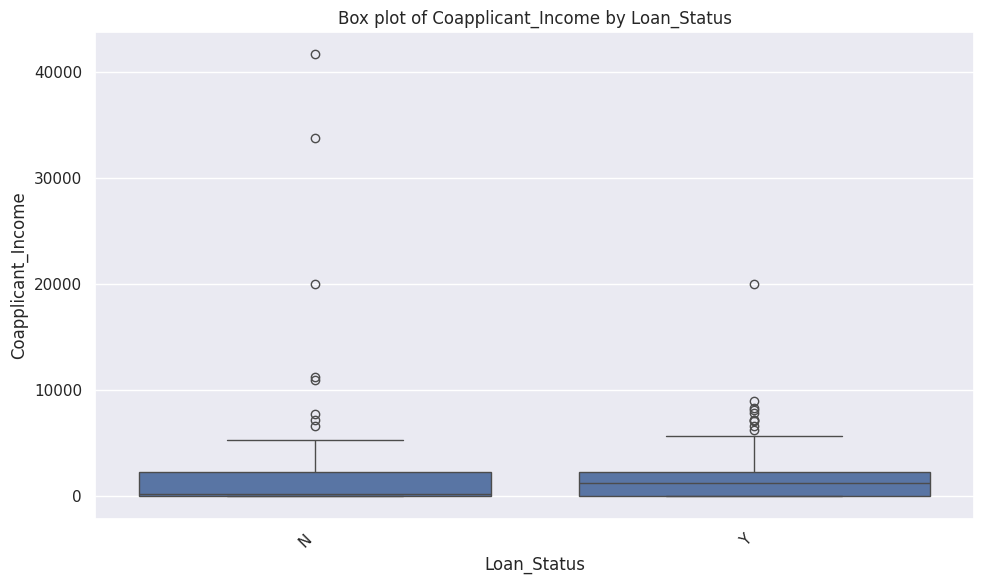

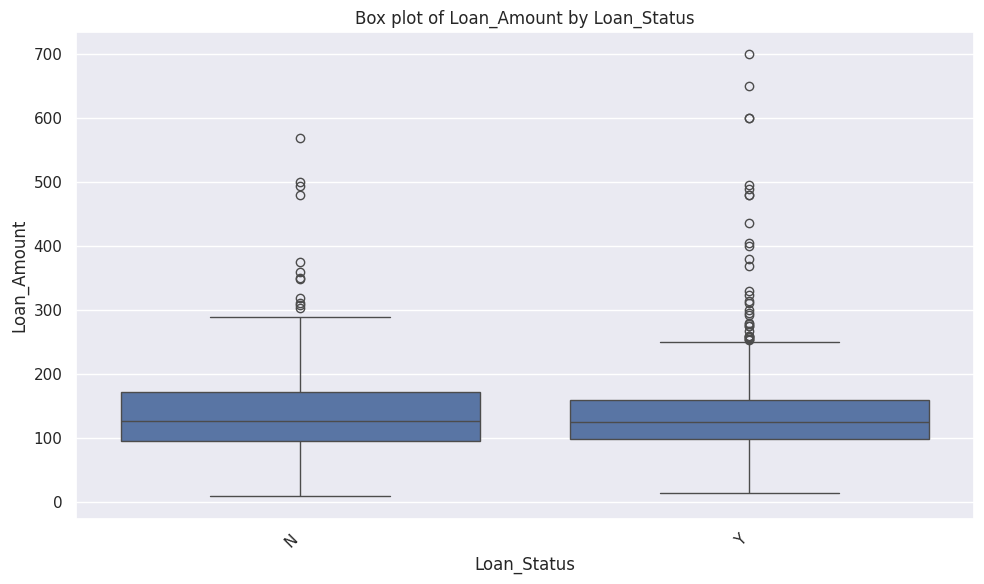

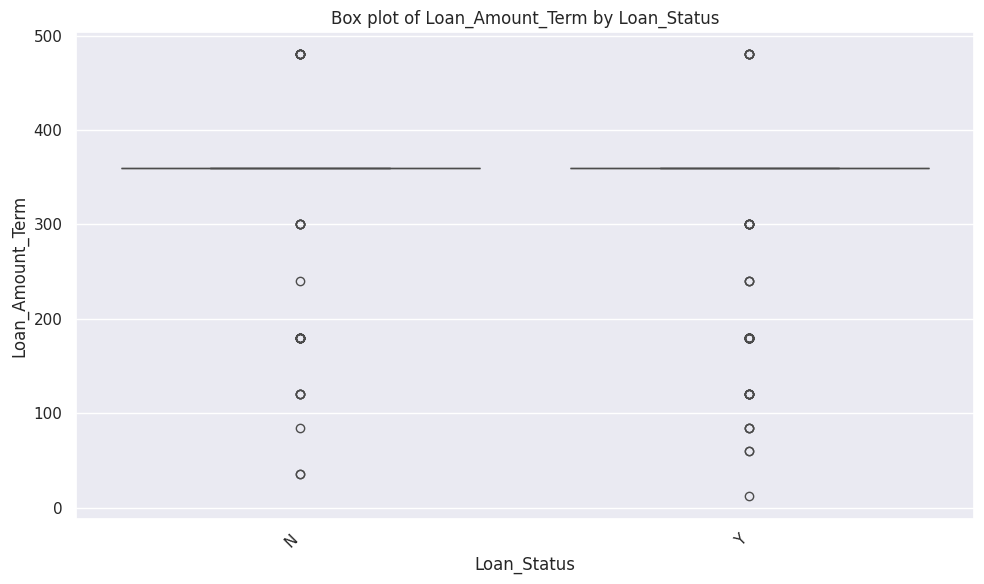

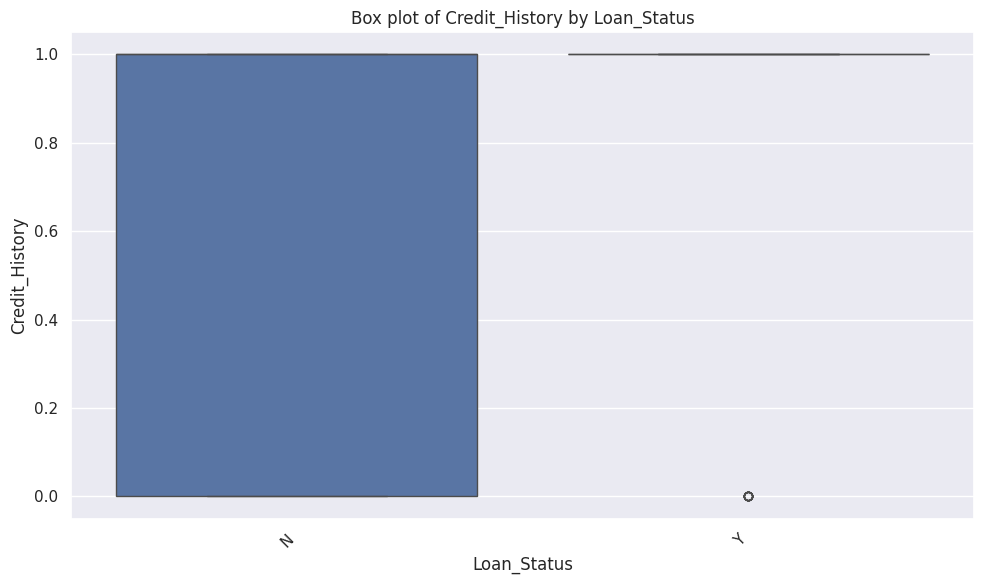

In [20]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

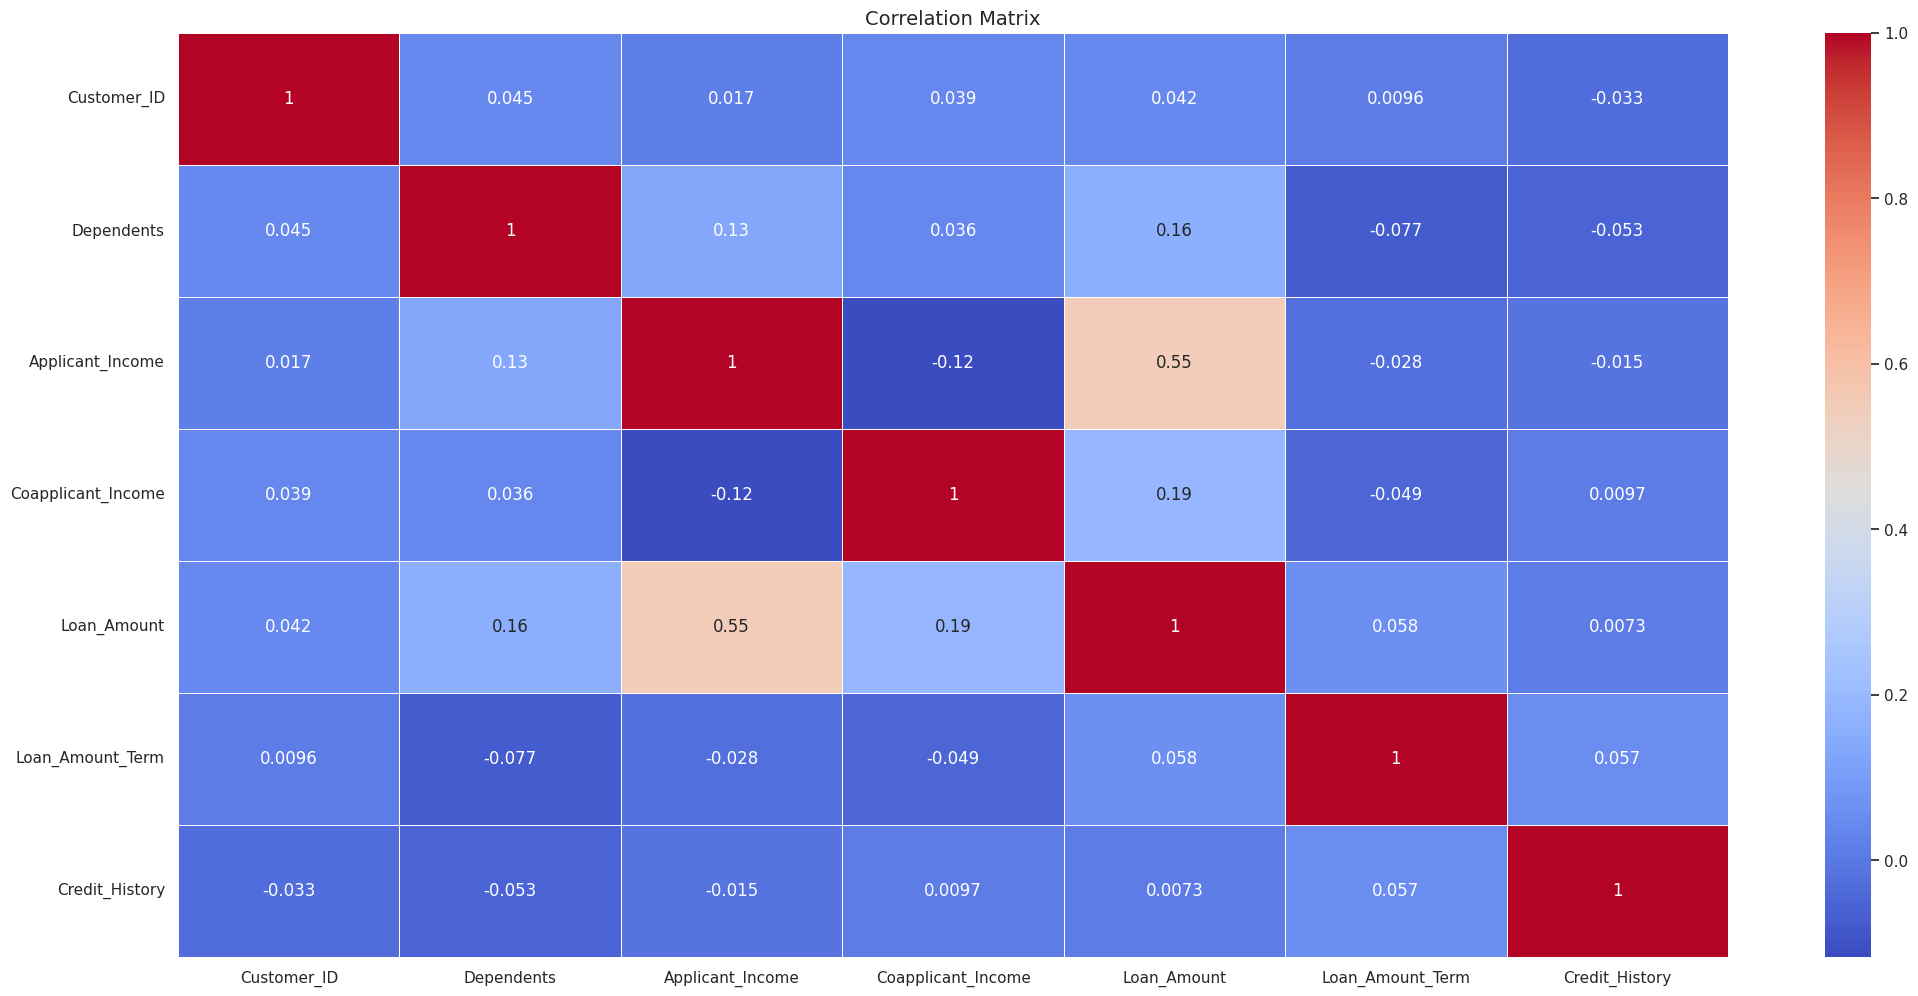

In [21]:
plt.figure(figsize=(25, 12))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You